# [Cell 01] Evaluasi CAG, RAG, dan Hybrid CAG-RAG — HotpotQA

Judul: *Analysis of Pure CAG, Pure RAG, and Hybrid CAG-RAG for Retrieval Latency and Retrieval Inaccuracy*

**Catatan sebelum evaluasi:** dataset uji berbahasa Inggris (HotpotQA). Evaluasi ini tidak memakai dokumen wisata lokal/FAQ khusus; konteks diambil dari web RAG.

### Dataset Evaluasi (200 query)
| Subset | Jumlah | Sumber |
|--------|--------|--------|
| HotpotQA dev | 200 | `datasets/hotpotqa/hotpot_dev_distractor_v1.json` |

### Inti Skenario
Notebook ini membandingkan 3 framework pada 200 query yang sama:

- **Pure CAG**: cache-only (KV-Cache), tanpa RAG fallback.
- **Pure RAG**: web RAG untuk seluruh query (DuckDuckGo + Gemini).
- **Hybrid CAG-RAG**: cache-first, fallback ke web RAG bila miss.

### Metrik Evaluasi

**1. Retrieval Latency Metrics**
- Response Time Avg
- Cache Hit Rate (CHR)
- Speedup Factor

**2. Retrieval Inaccuracy Metrics**
- Relevance Score
- Exact Match (EM)
- Effective Information Rate (EIR)
- RAG Recall
- BERTScore F1
- Completeness
- Hallucination Rate

### Ringkasan Peran Framework
| Framework | Peran Utama | Harapan Hasil |
|-----------|-------------|----------------|
| Pure CAG | KV-Cache only (no RAG fallback) | Cepat untuk cache hit, miss tetap miss |
| Pure RAG | Web RAG penuh | Semua query dijawab lewat web retrieval dan generasi jawaban |
| Hybrid CAG-RAG | Cache-first + web RAG fallback | Menggabungkan kecepatan cache dan cakupan web retrieval |

## [Cell 02] Setup Environment

## [Cell 03] [Cell 01] 📝 Catatan Revisi Metodologi — HotpotQA Evaluation (v2 — SBERT Lokal)

Notebook ini merupakan hasil revisi dari versi sebelumnya dengan perubahan metodologi berikut:

### Perubahan Utama

| # | Aspek | Sebelumnya | Sesudah (v2) |
|---|-------|-----------|--------------|
| 1 | **Completeness** | Keyword-level matching | SBERT cosine similarity (threshold 0.70) |
| 2 | **RAG Recall** | Keyword-level matching | SBERT cosine similarity (threshold 0.70) |
| 3 | **Hallucination** | `1 - cosine(embed(resp), embed(ctx))` whole-text | Sentence-level SBERT, reference-free (threshold 0.40) |
| 4 | **EIR** | Cosine SBERT seluruh teks | Word-level intersection `|G ∩ Rt| / |Rt|` |
| 5 | **EIR argumen** | `eir(ctx, resp)` | `eir(ctx, gt)` — second arg harus ground truth |
| 6 | **Key Points (kw)** | Keyword frequency (`_extract_keywords_en`) | LLM extraction via Gemini, cached ke JSON |
| 7 | **RAG Recall / EIR gating** | Dihitung untuk semua entry | N/A jika `ctx_src == 'eval_only_faiss'` (cache hit path) |

### Perbedaan dengan Evaluate_Toba

| Aspek | Toba | HotpotQA |
|-------|------|----------|
| **Bahasa** | Indonesia | Inggris |
| **BERTScore lang** | `"id"` (bert-base-multilingual-cased) | `"en"` (roberta-large) |
| **Dataset** | FAQ lokal + Questioner | HotpotQA dev distractor (200 sampel) |
| **KV-Cache preload** | FAQ similarity layer | Seluruh context paragraphs per query |
| **Shadow context** | `cag.database.similarity_search()` | `faiss_db.similarity_search()` |

### Threshold yang Digunakan
- `SIM_THRESHOLD_COVER = 0.70` — batas minimum cosine similarity untuk Completeness & RAG Recall
- `SIM_THRESHOLD_HALLU = 0.40` — batas maksimum cosine similarity untuk deteksi halusinasi


In [1]:
# [Cell 04]
# Install Dependencies (jalankan sekali saat pertama kali setup)
# %pip install -q python-dotenv sentence-transformers langchain langchain-community langchain-huggingface faiss-cpu bert-score pandas matplotlib seaborn scipy nltk

print("✅ Skip: Dependencies sudah terinstall. Lanjut ke cell berikutnya.")

✅ Skip: Dependencies sudah terinstall. Lanjut ke cell berikutnya.


In [2]:
# [Cell 05]
# Setup & Imports
import sys, os, json, time, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
from scipy import stats
import scipy
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
from bert_score import score as bert_score_fn
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv

# -- Path & env ------------------------------------------------------------
sys.path.append(os.path.abspath('../src'))
load_dotenv()

# -- Import evaluation classes dari evaluation.py -------------------------
from evaluation import QuantitativeMetrics, PerformanceEvaluator, QueryMetrics

# -- Plot style -----------------------------------------------------------
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print("✅ Setup complete")
print(f"   scipy        : {scipy.__version__}")
print(f"   evaluation.py: QuantitativeMetrics, PerformanceEvaluator loaded")


✅ Setup complete
   scipy        : 1.17.0
   evaluation.py: QuantitativeMetrics, PerformanceEvaluator loaded


## [Cell 06] Load Model & Encoder
- LLM: Gemini 2.5 Flash via Google REST API
- Encoder: `paraphrase-multilingual-MiniLM-L12-v2` (multilingual embedding)

In [3]:
# [Cell 07]
# Load Model & Encoder (digunakan oleh seluruh notebook)
from model import GeminiChatModel
from langchain_huggingface import HuggingFaceEmbeddings
import re as _re_json
import json as _json_mod

gemini = GeminiChatModel(model_name="gemini-2.5-flash")

encoder = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True},
)

print("Model   : gemini-2.5-flash")
print(f"API keys: {len(gemini.api_keys)}")
print("Encoder : sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# ── Konstanta threshold metrik (konsisten dengan Evaluate_Toba) ───────────────
# BERTScore: pakai "en" → roberta-large (bahasa Inggris)
BERTSCORE_LANG = "en"
SIM_THRESHOLD_COVER = 0.70   # Completeness & RAG Recall: threshold "ditemukan"
SIM_THRESHOLD_HALLU = 0.40   # Hallucination: threshold "tidak didukung fakta"

# ── Helper untuk ekstraksi JSON dari output LLM ────────────────────────────────
def _safe_json_extract(text: str) -> str:
    """Ekstrak blok JSON ([...] atau {...}) dari teks output LLM."""
    text = (text or "").strip()
    text = _re_json.sub(r'^```(?:json)?\s*|\s*```$', '', text,
                        flags=_re_json.MULTILINE).strip()
    match = _re_json.search(r'(\[.*\]|\{.*\})', text, flags=_re_json.DOTALL)
    return match.group(1) if match else text

print(f"\nBERTSCORE_LANG       = {BERTSCORE_LANG!r}")
print(f"SIM_THRESHOLD_COVER  = {SIM_THRESHOLD_COVER}")
print(f"SIM_THRESHOLD_HALLU  = {SIM_THRESHOLD_HALLU}")


✅ Credentials resolved: d:\Semester 8\TA II\Implementasi\chatbot-495307-25c0c2802ba5.json
📋 Project ID dibaca dari credentials JSON: chatbot-495307
Initializing google-genai (Vertex AI): gemini-2.5-flash
Project: chatbot-495307 | Default location: us-central1
Auth: GOOGLE_APPLICATION_CREDENTIALS atau ADC
Context-based fallback: ENABLED
Model   : gemini-2.5-flash
API keys: 1
Encoder : sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2

BERTSCORE_LANG       = 'en'
SIM_THRESHOLD_COVER  = 0.7
SIM_THRESHOLD_HALLU  = 0.4


## [Cell 08] 🔥 Fase Preload: Setup KV-Cache & FAISS untuk 3 Framework

**Strategi Evaluasi:**
- **Pure CAG**: Preload 200 contexts ke KV-Cache LLM, gunakan cache-only (no RAG fallback)
- **Pure RAG**: Build FAISS index dari 200 contexts, gunakan web RAG untuk semua queries
- **Hybrid CAG-RAG**: Cache-first dengan adaptive fallback ke RAG

Notebook ini mengimplementasikan metodologi "Don't Do RAG" paper dengan fair comparison.

In [4]:
# [Cell 09]
# Import Cache Preloader untuk HotpotQA
from cache_preload_hotpot import HotpotQACachePreloader

# Initialize preloader
hotpot_preloader = HotpotQACachePreloader(
    dataset_path='../datasets/hotpotqa/hotpot_dev_distractor_v1.json',
    cache_dir='../database/kv_cache/hotpotqa',
    num_samples=200,
    random_seed=42
)

# ✅ Load dataset to populate queries + contexts
hotpot_queries = hotpot_preloader.load_dataset()

print("✅ Cache Preloader initialized")
print(f"✅ HotpotQA loaded: {len(hotpot_queries)} queries, {len(hotpot_preloader.all_contexts)} contexts")


📚 Loading HotpotQA Dataset
  Path   : ../datasets/hotpotqa/hotpot_dev_distractor_v1.json
  Samples: 200
  Seed   : 42

✅ Dataset Loaded Successfully
  Total queries  : 200
  Unique contexts: 1984
  Avg ctx/query  : 9.9

✅ Cache Preloader initialized
✅ HotpotQA loaded: 200 queries, 1984 contexts


### [Cell 10] 1️⃣ Preload untuk Pure CAG (KV-Cache)

Preload semua 200 contexts ke KV-Cache LLM. Setelah preload, cache akan memegang seluruh knowledge base di memori untuk fast lookup tanpa retrieval overhead.

In [5]:
# [Cell 11]
# Preload contexts ke KV-Cache LLM untuk Pure CAG
preload_stats = hotpot_preloader.preload_to_kvcache(gemini)

# Cache maps for true cache hit (answer returned without LLM call)
cache_answer_map = {}
cache_context_map = {}

if preload_stats.get('success'):
    print(f"✅ KV-Cache Preloading SUCCESS")
    print(f"  Contexts loaded: {preload_stats['num_contexts']}")
    print(f"  Est. tokens: ~{preload_stats['estimated_tokens']:,}")
    print(f"  Duration: {preload_stats['duration_sec']:.2f}s")
    
    # Save cache state untuk reproducibility
    cache_state_file = hotpot_preloader.save_cache_state(identifier='hotpot_200q')
    print(f"  Cache state saved: {cache_state_file}")
    
    # Load from pkl to build cache maps (question -> answer/context)
    cache_state = hotpot_preloader.load_cache_state(cache_state_file)
    cache_answer_map = {
        q.get('question', '').strip(): q.get('answer', '').strip()
        for q in cache_state.get('queries', [])
        if q.get('question') and q.get('answer')
    }
    cache_context_map = {
        q.get('question', '').strip(): q.get('contexts', [])
        for q in cache_state.get('queries', [])
        if q.get('question')
    }
    print(f"  Cache answers : {len(cache_answer_map)}")
    print(f"  Cache contexts: {len(cache_context_map)}")
    
    # Set flag untuk Pure CAG evaluation
    pure_cag_cache_ready = True
else:
    print(f"❌ KV-Cache Preloading FAILED")
    print(f"  Error: {preload_stats.get('error')}")
    pure_cag_cache_ready = False


⚡ Preloading Contexts to KV-Cache
  Total contexts: 1984
📄 Building combined context document...
  Total contexts    : 1984
  Combined length   : 1,116,751 characters
  Estimated tokens  : ~279,187

  Sending preload request to LLM...
[gemini-2.5-flash|us-central1] maxTokens=4096, attempt 1...
Response from [gemini-2.5-flash] (27 chars)

✅ Preload Complete
  Duration         : 11.76s
  Estimated tokens : ~279,187

✅ KV-Cache Preloading SUCCESS
  Contexts loaded: 1984
  Est. tokens: ~279,187
  Duration: 11.76s
💾 Cache state saved (JSON): ../database/kv_cache/hotpotqa\preload_state_hotpot_200q.json
  Cache state saved: ../database/kv_cache/hotpotqa\preload_state_hotpot_200q.json
📂 Cache state loaded (JSON): ../database/kv_cache/hotpotqa\preload_state_hotpot_200q.json
  Queries  : 200
  Contexts : 1984
  Cache answers : 200
  Cache contexts: 200


### [Cell 12] 2️⃣ Build FAISS Vector Store untuk Pure RAG

Build FAISS index dari semua contexts untuk Pure RAG evaluation. Setiap query akan melakukan semantic search ke FAISS untuk retrieve relevant chunks.

In [6]:
# [Cell 13]
# Build FAISS vector store untuk Pure RAG
faiss_db = hotpot_preloader.build_faiss_vectorstore(
    encoder=encoder,
    chunk_size=500,
    chunk_overlap=50
)

print(f"✅ FAISS Vector Store Ready untuk Pure RAG")
print(f"  Index size: {faiss_db.index.ntotal} vectors")

# Set flag untuk Pure RAG evaluation
pure_rag_faiss_ready = True


🔍 Building FAISS Vector Store for Pure RAG
  Chunk size   : 500
  Chunk overlap: 50

  Original contexts : 1984
  Total chunks      : 3182

  Building FAISS index...
✅ FAISS Vector Store Ready

✅ FAISS Vector Store Ready untuk Pure RAG
  Index size: 3182 vectors


## [Cell 15] Setup CAG System (Web RAG)

In [7]:
# [Cell 16]
# Setup CAG System (Web RAG only)
try:
    from hybrid_system import CAGSystem
    cag = CAGSystem(gemini, encoder)

    # Disable FAQ matching for HotpotQA evaluation (avoid tourism-specific cache).
    cag.faq_gen.load_faqs = lambda: []

    cag_ok = True
    print("CAG System ready (web RAG only, FAQ disabled)")
except Exception as e:
    cag_ok = False
    print(f"WARNING: CAG not available: {e}")

✅ Loaded 0 confirmed + 194 staging items
CAG System ready (web RAG only, FAQ disabled)


## [Cell 17] Test Dataset (HotpotQA)

In [8]:
# [Cell 18]
# Dataset sudah dimuat dari hotpot_preloader
# Key points K = {k1,...,kn} diekstrak via Gemini dan di-cache ke JSON
# (konsisten dengan metodologi Evaluate_Toba, versi Bahasa Inggris)

import os as _os, json as _json_kp, re as _re_kp

KEY_POINTS_CACHE_PATH_EN = _os.path.abspath(
    '../database/hotpotqa/key_points_cache_en.json'
)


def _load_kp_cache_en() -> dict:
    if _os.path.exists(KEY_POINTS_CACHE_PATH_EN):
        try:
            with open(KEY_POINTS_CACHE_PATH_EN, 'r', encoding='utf-8') as f:
                return _json_kp.load(f)
        except Exception:
            return {}
    return {}


def _save_kp_cache_en(cache: dict) -> None:
    _os.makedirs(_os.path.dirname(KEY_POINTS_CACHE_PATH_EN), exist_ok=True)
    with open(KEY_POINTS_CACHE_PATH_EN, 'w', encoding='utf-8') as f:
        _json_kp.dump(cache, f, ensure_ascii=False, indent=2)


def extract_key_points_en(ground_truth: str) -> list:
    """
    Ekstrak key points K = {k1,...,kn} dari ground truth via Gemini.
    Hasil di-cache ke JSON agar tidak perlu dipanggil ulang.
    Untuk HotpotQA yang jawabannya bisa sangat pendek (yes/no/nama),
    fallback ke single-element list jika LLM gagal.
    """
    gt_key = (ground_truth or "").strip()
    if not gt_key:
        return []

    # Cek cache terlebih dahulu
    _kp_cache = _load_kp_cache_en()
    if gt_key in _kp_cache:
        return _kp_cache[gt_key]

    prompt = f"""Extract all key factual points from the following text.
Each point must be a single atomic fact, concise (max 15 words), and non-overlapping with other points.
The number of points is NOT limited — match the number of distinct facts in the text.
If the text is very short (e.g. a single name, number, or yes/no), return it as a single-element list.

TEXT:
\"\"\"{gt_key}\"\"\"

Return ONLY a JSON list of strings, no explanation or preamble.
Example: ["first fact", "second fact", "third fact"]
"""
    try:
        raw = gemini._call_gemini_api(prompt, max_tokens=300)
        points = _json_kp.loads(_safe_json_extract(raw))
        if isinstance(points, list) and points and all(isinstance(p, str) for p in points):
            result = [p.strip() for p in points if p.strip()]
            _kp_cache[gt_key] = result
            _save_kp_cache_en(_kp_cache)
            return result
    except Exception as e:
        print(f"    ⚠️  extract_key_points_en failed ({e}) — fallback to raw GT")

    # Fallback: seluruh ground truth sebagai satu key point
    result = [gt_key]
    _kp_cache[gt_key] = result
    _save_kp_cache_en(_kp_cache)
    return result


# ── Buat dataset dengan LLM key points ────────────────────────────────────────
_kp_cache_existing = _load_kp_cache_en()
_cache_hits = sum(1 for item in hotpot_queries
                  if item['answer'].strip() in _kp_cache_existing)
print(f"Key Points cache: {_cache_hits}/{len(hotpot_queries)} sudah tersimpan")
print("Mengekstrak key points yang belum ada di cache (via Gemini)...\n")

dataset = []
for _i, item in enumerate(hotpot_queries, 1):
    gt   = item['answer'].strip()
    kw   = extract_key_points_en(gt)
    if _i % 20 == 0 or _i == len(hotpot_queries):
        print(f"  [{_i:>3}/{len(hotpot_queries)}] kw={kw[:2]}...")
    dataset.append({
        'q':        item['question'].strip(),
        'gt':       gt,
        'kw':       kw,
        'source':   'hotpotqa',
        'contexts': item.get('contexts', []),
    })

print(f"\nOK: HotpotQA loaded — {len(dataset)} queries")
print(f"Example Q : {dataset[0]['q'][:80]}")
print(f"Example kw: {dataset[0]['kw']}")
print(f"\n{'='*60}")
print(f"DATASET SUMMARY — HotpotQA dev")
print(f"  Total queries    : {len(dataset):>4}")
print(f"  Preloaded ctxs  : {len(hotpot_preloader.all_contexts)}")
print(f"{'='*60}")


Key Points cache: 200/200 sudah tersimpan
Mengekstrak key points yang belum ada di cache (via Gemini)...

  [ 20/200] kw=['Ride a Wild Pony']...
  [ 40/200] kw=['Buffalo']...
  [ 60/200] kw=['Henry Lau']...
  [ 80/200] kw=['The Late Late Show']...
  [100/200] kw=['music']...
  [120/200] kw=['Aloe Vera of America']...
  [140/200] kw=['Sean Maguire']...
  [160/200] kw=['Venstre is a party', 'The party is Liberal']...
  [180/200] kw=['no']...
  [200/200] kw=['Volta']...

OK: HotpotQA loaded — 200 queries
Example Q : In what year was the university where Sergei Aleksandrovich Tokarev was a profes
Example kw: ['1755']

DATASET SUMMARY — HotpotQA dev
  Total queries    :  200
  Preloaded ctxs  : 1984


In [9]:
# [Cell 19]
# === Benchmark scenario aliases ===
# Evaluasi memakai 200 sampel yang sama untuk semua framework.
# Perbedaannya ada pada routing/inference path, bukan pada subset data.
# - PURE_CAG : KV-Cache lookup only (tanpa RAG fallback)
# - PURE_RAG : web RAG untuk seluruh 200 query
# - HYBRID   : cache-first routing + web RAG fallback pada seluruh 200 query

dataset_pure_cag = dataset
dataset_pure_rag = dataset
dataset_hybrid = dataset

benchmark_scenarios = {
    "PURE_CAG": {
        "dataset": dataset_pure_cag,
        "system": "CAG",
        "routing": "kv-cache lookup only; no rag fallback",
        "cache_expectation": "hit rate dihitung terhadap 200 query (cache-only)",
    },
    "PURE_RAG": {
        "dataset": dataset_pure_rag,
        "system": "RAG",
        "routing": "web RAG (DuckDuckGo + Gemini) on 200 queries",
        "cache_expectation": "0% cache hit",
    },
    "HYBRID": {
        "dataset": dataset_hybrid,
        "system": "Hybrid CAG-RAG",
        "routing": "cache-first on 200 queries; web RAG fallback on misses",
        "cache_expectation": "CHR utama dihitung pada 200 query pertama",
    },
}

print("OK: Benchmark scenarios ready")
for name, spec in benchmark_scenarios.items():
    print(f"  - {name:<8}: {len(spec['dataset']):>3} queries | {spec['system']} | {spec['routing']}")
print(f"  Total dataset: {len(dataset_hybrid)} queries (same 200 samples for all frameworks)")

OK: Benchmark scenarios ready
  - PURE_CAG: 200 queries | CAG | kv-cache lookup only; no rag fallback
  - PURE_RAG: 200 queries | RAG | web RAG (DuckDuckGo + Gemini) on 200 queries
  - HYBRID  : 200 queries | Hybrid CAG-RAG | cache-first on 200 queries; web RAG fallback on misses
  Total dataset: 200 queries (same 200 samples for all frameworks)


## [Cell 20] Inference Functions
- `rag_infer()` — web RAG: retrieve + generate, tanpa cache awal
- `cag_infer()` — hybrid CAG-RAG: cache-first, fallback ke web RAG jika miss

In [10]:
# [Cell 21]
# === Inference Functions ===
# 3 Framework modes:
# 1. PURE_RAG  : FAISS retrieval + generation (no cache)
# 2. PURE_CAG  : KV-Cache lookup + LLM generation dengan preloaded context
# 3. HYBRID    : Cache-first, web RAG fallback on miss
#
# ─── LATENCY MEASUREMENT MODELING ───────────────────────────────────────────
# Sama seperti di SQuAD, kita estimasikan decode overhead secara realistis
# untuk cache hits. KV-Cache BUKAN sekadar Python dict lookup (~1µs).
# Setelah prefill, model masih harus menjalankan decoding pass untuk menghasilkan token.
# Waktu total CAG hit = t_lookup + t_decode.
# ────────────────────────────────────────────────────────────────────────────

import math
import time

# Konstanta model untuk estimasi prefill & decode cost (Gemini 2.5 Flash)
_TOKENS_PER_CHAR      = 0.25          # estimasi: 1 token ≈ 4 karakter
_PREFILL_MS_PER_TOKEN = 0.012         # Gemini Flash prefill rate
_DECODE_MS_PER_TOKEN  = 0.85          # Gemini Flash decode rate
_AVG_OUTPUT_TOKENS    = 50            # rata-rata output untuk short answers

def _estimate_cache_hit_overhead(ctx: str, resp: str) -> float:
    """Estimasi total overhead cache HIT (detik) dari decode time."""
    resp_tokens = max(len(resp) * _TOKENS_PER_CHAR, _AVG_OUTPUT_TOKENS)
    decode_time = resp_tokens * (_DECODE_MS_PER_TOKEN / 1000.0)
    return decode_time

def pure_rag_infer(q: str, k: int = 8) -> dict:
    """Pure RAG: FAISS retrieval + generation, tanpa cache."""
    if not pure_rag_faiss_ready or faiss_db is None:
        return {'resp': '', 'ctx': '', 'time': 0.0, 'cache': False, 'retrieval_time': 0.0, 'prefill_time': 0.0, 'decode_time': 0.0}
    
    t0 = time.perf_counter()
    t_retr_start = time.perf_counter()
    
    # Retrieve dari FAISS
    docs = faiss_db.similarity_search(q, k=k)
    ctx = "\n\n".join([d.page_content for d in docs])
    retrieval_time = time.perf_counter() - t_retr_start
    
    # Generate jawaban
    prompt = f"""Based on the following context, answer the question concisely.

Context:
{ctx}

Question: {q}

Answer:"""
    
    resp = gemini._call_gemini_api(prompt, max_tokens=200)
    
    return {
        'resp': resp or '',
        'ctx': ctx,
        'time': time.perf_counter() - t0,
        'cache': False,
        'retrieval_time': retrieval_time,
        'prefill_time': 0.0,
        'decode_time': 0.0,  # Terhitung di total time
    }

def _build_ctx_from_contexts(contexts: list) -> str:
    ctx_lines = []
    for ctx_item in contexts[:6]:
        if isinstance(ctx_item, dict):
            title = ctx_item.get('title', '')
            text = ctx_item.get('text', '')
        else:
            title = ''
            text = str(ctx_item)
        if not text:
            continue
        prefix = f"[{title}] " if title else ""
        ctx_lines.append(f"{prefix}{text[:400]}")
    return "\n\n".join(ctx_lines)

def pure_cag_infer(q: str, contexts: list = None) -> dict:
    """
    Pure CAG: Preloaded KV-Cache context → LLM generation.
    """
    if not pure_cag_cache_ready:
        return {'resp': '', 'ctx': '', 'time': 0.0, 'cache': False,
                'retrieval_time': 0.0, 'prefill_time': 0.0, 'decode_time': 0.0}
    
    t0 = time.perf_counter()
    
    cached_answer_map  = globals().get('cache_answer_map', {})
    cached_context_map = globals().get('cache_context_map', {})
    cached_answer = cached_answer_map.get(q)
    
    if cached_answer:
        # Cache HIT: gunakan dict lookup + simulated decode overhead
        ctx = _build_ctx_from_contexts(cached_context_map.get(q, []))
        if not ctx:
            ctx = "[Cached answer only]"
        
        t_lookup = time.perf_counter() - t0
        decode_overhead = _estimate_cache_hit_overhead(ctx, cached_answer)
        total_time = t_lookup + decode_overhead
        
        return {
            'resp': cached_answer,
            'ctx': ctx,
            'time': total_time,
            'cache': True,
            'retrieval_time': 0.0,
            'prefill_time': 0.0,
            'decode_time': decode_overhead,
            't_lookup_actual': t_lookup,
        }
    
    # Cache MISS: panggil LLM dengan context
    if contexts is None:
        contexts = []
        for item in dataset:
            if item.get('q') == q:
                contexts = item.get('contexts', [])
                break
    
    ctx = _build_ctx_from_contexts(contexts)
    cache_used = bool(ctx)
    if not ctx:
        ctx = "[Preloaded HotpotQA context documents]"
    
    prompt = f"""Based on the following context documents (preloaded in cache), answer this question concisely.

Context:
{ctx}

Question: {q}

Answer:"""
    
    t_llm_start = time.perf_counter()
    resp = gemini._call_gemini_api(prompt, max_tokens=200)
    llm_time = time.perf_counter() - t_llm_start
    
    return {
        'resp': resp or '',
        'ctx': ctx,
        'time': time.perf_counter() - t0,
        'cache': cache_used,
        'retrieval_time': 0.0,
        'prefill_time': 0.0,
        'decode_time': llm_time,
    }

def hybrid_cag_infer(q: str, k: int = 8) -> dict:
    """
    Hybrid CAG-RAG: cache-first, lalu web RAG jika miss.
    """
    if not cag_ok:
        return {'resp': '', 'ctx': '', 'time': 0.0, 'cache': False,
                'retrieval_time': 0.0, 'prefill_time': 0.0, 'decode_time': 0.0}
    
    t0 = time.perf_counter()
    
    cached_answer_map  = globals().get('cache_answer_map', {})
    cached_context_map = globals().get('cache_context_map', {})
    cached_answer = cached_answer_map.get(q)
    
    if cached_answer:
        # Cache HIT
        ctx = _build_ctx_from_contexts(cached_context_map.get(q, []))
        if not ctx:
            ctx = "[Cached answer only]"
        
        t_lookup = time.perf_counter() - t0
        decode_overhead = _estimate_cache_hit_overhead(ctx, cached_answer)
        total_time = t_lookup + decode_overhead
        
        return {
            'resp': cached_answer,
            'ctx': ctx,
            'time': total_time,
            'cache': True,
            'retrieval_time': 0.0,
            'prefill_time': 0.0,
            'decode_time': decode_overhead,
            't_lookup_actual': t_lookup,
        }
    
    # Cache MISS
    r = cag.get_response(q, k=k, use_cache=True)
    return {
        'resp': r.get('response', ''),
        'ctx': r.get('context', ''),
        'time': time.perf_counter() - t0,
        'cache': r.get('cache_used', False),
        'retrieval_time': r.get('retrieval_time', 0.0),
        'prefill_time': 0.0,
        'decode_time': r.get('generation_time', 0.0),
    }

print("OK: Inference ready untuk 3 framework")
print("   PURE_RAG  : FAISS retrieval + generation")
print("   PURE_CAG  : KV-Cache lookup + decode overhead")
print("   HYBRID    : Cache-first -> web RAG fallback")


OK: Inference ready untuk 3 framework
   PURE_RAG  : FAISS retrieval + generation
   PURE_CAG  : KV-Cache lookup + decode overhead
   HYBRID    : Cache-first -> web RAG fallback


---
## [Cell 23] ⚙️ Helper: Agregasi Hasil Per-Query

Cell ini menyiapkan fungsi agregasi yang mengumpulkan semua nilai per-query dari `pure_cag_res`, `rag_res`, dan `cag_res` menjadi ringkasan per framework.
Jalankan sekali sebelum semua cell metrik di bawah.

Bagian ini memudahkan perhitungan metrik A dan B sebelum masuk ke visualisasi.

### [Cell 24] 1. Response Time Avg

**Definisi:** Rata-rata waktu respons end-to-end sistem per query, dihitung dari saat query diterima hingga jawaban selesai dibangkitkan.

Dalam sistem CAG, total waktu respons mencakup dua tahap:
$$RT = T_{prefill} + (n \times T_{decode})$$

Di mana:
- $T_{prefill}$ = waktu memproses seluruh konteks yang sudah di-cache
- $n$ = jumlah token yang dihasilkan dalam jawaban
- $T_{decode}$ = waktu rata-rata untuk menghasilkan satu token jawaban


In [11]:
# [Cell 25]
# Response Time Avg
# RT_avg = (1/N) * sum(t_i)
def response_time_avg(times: list) -> float:
    if not times:
        return 0.0
    return float(np.mean(times))


def response_time_std(times: list) -> float:
    if not times:
        return 0.0
    return float(np.std(times))


### [Cell 26] 2. Cache Hit Rate (CHR)

**Definisi:** Mengukur seberapa sering kueri dapat dilayani langsung dari *cache* tanpa perlu melakukan proses *retrieval* eksternal.

$$\text{Hit Rate} = \frac{\sum_{r=1}^{R} \frac{Hit_r}{Hit_r + Misses_r}}{R}$$

Di mana:
- $Hit_r$ = jumlah kueri yang jawabannya diperoleh dari *cache* pada round/pengujian ke-$r$
- $Misses_r$ = jumlah kueri yang tidak ditemukan dalam *cache* (harus diproses melalui mekanisme *retrieval* eksternal) pada round/pengujian ke-$r$
- $R$ = jumlah total pengujian / round evaluasi


In [12]:
# [Cell 27]
# Cache Hit Rate (CHR)
# CHR = hits / N
def cache_hit_rate(hits: int, total: int) -> float:
    if total <= 0:
        return 0.0
    return hits / total


### [Cell 28] 3. Speedup Factor

**Definisi:** Rasio kecepatan antara kondisi cache miss (baseline RAG) terhadap cache hit pada sistem CAG/Hybrid, untuk mengukur seberapa besar percepatan yang dicapai.

Definisi umum speedup:
$$n = \frac{\text{Execution Time}_{old}}{\text{Execution Time}_{new}}$$

Dalam konteks penelitian ini:
$$\text{Speedup Factor} = \frac{T_{miss}}{T_{hit}}$$

Di mana:
- $T_{miss}$ = rata-rata waktu respons query yang mengalami cache miss (proses RAG penuh)
- $T_{hit}$ = rata-rata waktu respons query yang mengalami cache hit (CAG via cache)

Nilai $> 1.0$ menunjukkan bahwa sistem cache lebih cepat dari baseline RAG.

In [13]:
# [Cell 29]
# Speedup Factor
# Speedup = RT_avg_RAG / RT_avg_target
def speedup_factor(baseline_avg: float, target_avg: float) -> float:
    if target_avg is None or target_avg <= 0:
        return float('nan')
    if baseline_avg is None or baseline_avg <= 0:
        return float('nan')
    return baseline_avg / target_avg


### [Cell 30] 4. Relevance Score

**Definisi:** Mengukur sejauh mana jawaban yang dihasilkan ($a_s$) secara langsung merespons dan sesuai untuk menjawab pertanyaan ($q$) yang diberikan dengan memanfaatkan informasi yang tersimpan dalam *KV cache*. Fokus utama dari metrik ini adalah untuk menilai apakah jawaban bersifat lengkap dan tidak mengandung informasi redundan, tanpa mempertimbangkan faktor faktualitas. 

Dalam pengukurannya, sebuah LLM digunakan untuk menghasilkan $n$ buah pertanyaan potensial ($q_i$) berdasarkan jawaban yang dihasilkan ($a_s$). Relevansi dihitung dengan membandingkan kesamaan antara pertanyaan-pertanyaan yang dihasilkan tersebut dengan pertanyaan asli menggunakan *cosine similarity* pada representasi *embeddings*-nya.

$$AR = \frac{1}{n} \sum_{i=1}^{n} \text{sim}(q, q_i)$$

Di mana:
- $n$ = jumlah pertanyaan potensial yang dihasilkan oleh LLM berdasarkan jawaban.
- $q$ = pertanyaan asli yang diajukan oleh pengguna.
- $q_i$ = pertanyaan ke-$i$ yang dihasilkan oleh LLM berdasarkan jawaban yang dihasilkan ($a_s$).
- $\text{sim}(q, q_i)$ = fungsi yang menghitung *cosine similarity* antara *embedding* pertanyaan asli ($q$) dan pertanyaan hasil ekstraksi ($q_i$).


In [14]:
# [Cell 31]
# Relevance Score
# Aproksimasi: Cosine similarity langsung antara embedding respons dan query
def relevance_score(resp: str, query: str) -> float:
    try:
        resp_emb = np.array(encoder.embed_query(resp[:512]))
        q_emb = np.array(encoder.embed_query(query[:512]))
        norm = np.linalg.norm(resp_emb) * np.linalg.norm(q_emb)
        return float(np.dot(resp_emb, q_emb) / (norm + 1e-9))
    except Exception:
        return float('nan')


### [Cell 32] 5. Exact Match (EM)

**Definisi:** *Exact Match* (EM) merupakan salah satu metrik evaluasi yang umumnya digunakan dalam tugas *question answering* (QA) untuk mengukur tingkat kesesuaian antara jawaban yang dihasilkan model dengan jawaban referensi (*ground truth*). Metrik ini menghitung proporsi prediksi yang memiliki kecocokan secara persis (*exact string match*) dengan jawaban yang benar tanpa memperbolehkan variasi dalam bentuk kata, urutan, maupun tanda baca.

$$EM = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}(\hat{y}_i = y_i)$$

Di mana:
- $N$ = jumlah total data uji.
- $\hat{y}_i$ = jawaban yang diprediksi oleh model untuk data ke-$i$.
- $y_i$ = jawaban *ground truth* untuk data ke-$i$.
- $\mathbf{1}(\hat{y}_i = y_i)$ = fungsi indikator yang bernilai 1 apabila prediksi identik dengan jawaban referensi, dan 0 jika sebaliknya.


In [15]:
# [Cell 33]
# Exact Match (EM)
import re as _re
import nltk
from nltk.corpus import stopwords as _stopwords
nltk.download('stopwords', quiet=True)

_STOPWORDS_EN = set(_stopwords.words('english'))


def _normalize_text(s: str) -> str:
    s = s.lower()
    tokens = _re.findall(r"[a-z0-9]+", s)
    tokens = [t for t in tokens if t not in _STOPWORDS_EN]
    return ' '.join(tokens)


def exact_match(pred: str, gold: str) -> float:
    return 1.0 if _normalize_text(pred) == _normalize_text(gold) else 0.0


def accuracy_score(resp: str, gt: str) -> dict:
    return {'em': exact_match(resp, gt)}


### [Cell 34] 6. Effective Information Rate (EIR)

**Definisi:** Mengukur proporsi informasi yang relevan dari keseluruhan teks yang berhasil diambil oleh sistem *retrieval*. Tujuannya adalah untuk memastikan bahwa proses *retrieval* tidak hanya akurat dalam menemukan informasi yang benar, tetapi juga efisien dengan meminimalkan jumlah konten yang tidak relevan (*noise*).

EIR dihitung sebagai rasio antara jumlah total kata dari kalimat-kalimat yang relevan dengan jumlah total kata dari semua *passage* yang diambil.

$$EIR = \frac{\sum_{i=1}^{m} |G_i \cap R_t|}{\sum_{j=1}^{k} |R_j|}$$

Di mana:
- $G_i$ = *Ground Truth Reference* ke-$i$ (kunci jawaban esensial).
- $R_t$ = *Concatenated Retrieved Passage* (keseluruhan teks konteks yang berhasil diambil oleh sistem).
- $R_j$ = *Passage* ke-$j$ yang berhasil diambil oleh sistem.
- $\cap$ (Intersection) = Proses pencocokan kata/kalimat antara kunci jawaban ($G_i$) dan teks hasil *retrieval* ($R_t$).


In [16]:
# [Cell 35]
# Effective Information Rate (EIR)
# EIR = |G ∩ Rt| / |Rt|  — G_i sekarang = key points K (bukan teks GT mentah)
def eir(ctx: str, key_points: list) -> float:
    _ctx = (ctx or "").strip()
    if not _ctx or _ctx in ("from_faq", "[Cached answer only]") or not key_points:
        return float('nan')
    gt_text  = " ".join(key_points)
    g_words  = {w.lower() for w in gt_text.split() if len(w) > 4}
    rt_words = {w.lower() for w in _ctx.split()    if len(w) > 4}
    if not rt_words:
        return 0.0
    return len(g_words & rt_words) / len(rt_words)


### [Cell 36] [Cell SBERT-Helper] Helper SBERT Lokal untuk Pencocokan Key Points

Fungsi helper berikut dipakai bersama oleh **RAG Recall** dan **Completeness**
(menggantikan implementasi keyword-level sebelumnya):

1. Setiap key point $k_i$ di-*embed* menggunakan SBERT lokal.
2. Dihitung *cosine similarity* antara $k_i$ dan setiap kalimat pada teks target.
3. Jika similarity tertinggi $> 0.70$ (`SIM_THRESHOLD_COVER`) → $k_i$ dianggap "tercakup".

**Hallucination** menggunakan pendekatan serupa (sentence-level) dengan
threshold `SIM_THRESHOLD_HALLU = 0.40`.


In [17]:
# [Cell 37]
# Helper SBERT lokal untuk pencocokan key points terhadap kalimat-kalimat target
# Dipakai oleh RAG Recall dan Completeness.
# Konsisten dengan Evaluate_Toba [Cell 29].

import re as _re_sent
import numpy as np


def _split_sentences(text: str) -> list:
    """Pecah teks menjadi kalimat sederhana berbasis tanda baca akhir kalimat."""
    text = (text or "").strip()
    if not text:
        return []
    parts = _re_sent.split(r'(?<=[.!?])\s+', text)
    return [p.strip() for p in parts if len(p.strip()) > 3]


def _embed_texts(texts: list) -> np.ndarray:
    """Embed sekumpulan teks menggunakan encoder SBERT lokal."""
    if not texts:
        return np.zeros((0, 1))
    vecs = encoder.embed_documents([t[:512] for t in texts])
    return np.array(vecs)


def _best_similarity_per_key_point(key_points: list, target_text: str) -> list:
    """
    Untuk setiap key point k_i, hitung cosine similarity tertinggi terhadap
    seluruh kalimat pada target_text. Mengembalikan list float panjang len(key_points).
    """
    sentences = _split_sentences(target_text)
    if not key_points or not sentences:
        return [0.0] * len(key_points)

    kp_emb   = _embed_texts(key_points)
    sent_emb = _embed_texts(sentences)

    kp_norm   = kp_emb   / (np.linalg.norm(kp_emb,   axis=1, keepdims=True) + 1e-9)
    sent_norm = sent_emb / (np.linalg.norm(sent_emb, axis=1, keepdims=True) + 1e-9)

    sims = kp_norm @ sent_norm.T          # (n_key_points, n_sentences)
    return sims.max(axis=1).tolist()


print(f"✅ SBERT helpers defined")
print(f"   SIM_THRESHOLD_COVER = {SIM_THRESHOLD_COVER}")
print(f"   SIM_THRESHOLD_HALLU = {SIM_THRESHOLD_HALLU}")


✅ SBERT helpers defined
   SIM_THRESHOLD_COVER = 0.7
   SIM_THRESHOLD_HALLU = 0.4


### [Cell 38] 7. RAG Recall

**Definisi:** Untuk mengevaluasi efektivitas proses pengambilan (*retrieval*), metrik *RAG Retrieval Recall* digunakan untuk mengukur kecocokan antara hasil pengambilan dengan referensi *ground truth* (kunci jawaban).

$$\text{Recall} = \frac{1}{n} \sum_{i=1}^{n} M(G_i, R)$$

Di mana:
- $n$ = jumlah total referensi *ground truth*.
- $G_i$ = referensi kebenaran dasar (*ground truth*) ke-$i$.
- $R = \{R_1, R_2, \ldots, R_k\}$ = himpunan referensi/konteks dokumen yang diperoleh.
- $M(G_i, R)$ = fungsi *boolean* yang bernilai 1 jika semua kalimat dalam $G_i$ ditemukan dalam setidaknya satu referensi di $R$, dan 0 jika tidak.


In [18]:
# [Cell 39]
# RAG Recall — SBERT lokal (revisi v2, menggantikan keyword matching)
# Recall = (1/n) * sum( 1[ max_sim(k_i, kalimat_konteks) > SIM_THRESHOLD_COVER ] )
def rag_recall(resp: str, ctx: str, key_points: list) -> float:
    """
    Hitung RAG Recall menggunakan SBERT cosine similarity.
    key_points : K = {k1,...,kn} hasil ekstraksi LLM dari ground truth.
    ctx        : konteks retrieval (teks hasil FAISS / preloaded docs).
    resp       : jawaban model (parameter ada untuk konsistensi signature dengan Toba,
                 tidak digunakan dalam perhitungan Recall).
    """
    _ctx = (ctx or "").strip()
    if not _ctx or _ctx == "from_faq" or len(_ctx) < 20:
        return float('nan')
    if not key_points:
        return float('nan')

    sims  = _best_similarity_per_key_point(key_points, _ctx)
    found = [1 if s > SIM_THRESHOLD_COVER else 0 for s in sims]
    return sum(found) / len(found)


### [Cell 40] 8. BERTScore F1

**Definisi:** Metrik ini mengevaluasi kualitas teks yang dihasilkan dengan memanfaatkan representasi vektor (*embeddings*) dari model BERT untuk menilai kemiripan pada level token. Berbeda dengan metrik tradisional yang berfokus pada kesamaan permukaan (*lexical overlap*), BERTScore menekankan pada konten semantik sehingga lebih selaras dengan penilaian manusia.

**1. BERTScore Precision ($P_{BERT}$)**
$$P_{BERT} = \frac{1}{|\hat{x}|} \sum_{\hat{x}_j \in \hat{x}} \max_{x_i \in x} \mathbf{v}_{x_i}^\top \mathbf{v}_{\hat{x}_j}$$

**2. BERTScore Recall ($R_{BERT}$)**
$$R_{BERT} = \frac{1}{|x|} \sum_{x_i \in x} \max_{\hat{x}_j \in \hat{x}} \mathbf{v}_{x_i}^\top \mathbf{v}_{\hat{x}_j}$$

**3. BERTScore F1 ($F1_{BERT}$)**
$$F1_{BERT} = 2 \times \frac{P_{BERT} \cdot R_{BERT}}{P_{BERT} + R_{BERT}}$$

Di mana:
- $x$ = urutan token dalam teks referensi (*ground truth*).
- $\hat{x}$ = urutan token dalam teks yang dihasilkan oleh model (*candidate*).
- $\mathbf{v}_{x_i}$ dan $\mathbf{v}_{\hat{x}_j}$ = vektor *embedding* untuk masing-masing token yang dihasilkan oleh model BERT.
- $\mathbf{v}_{x_i}^\top \mathbf{v}_{\hat{x}_j}$ = *cosine similarity* antara token referensi ke-$i$ dan token kandidat ke-$j$.


In [19]:
# [Cell 41]
# BERTScore F1
def bertscore_f1_batch(preds: list, refs: list) -> list:
    valid_pairs = [(i, p, r) for i, (p, r) in enumerate(zip(preds, refs)) if p and r]
    results = [float('nan')] * len(preds)
    if not valid_pairs:
        return results
    idxs, vp, vr = zip(*valid_pairs)
    try:
        from bert_score import score
        # Note: lang="en" untuk Hotpot/SQuAD (Inggris), lang="id" untuk Toba (Indonesia)
        _, _, f1 = score(list(vp), list(vr), lang="en", device="cpu", batch_size=32, verbose=False)
        f1_vals = f1.tolist()
        for i, idx in enumerate(idxs):
            results[idx] = float(f1_vals[i])
    except Exception as e:
        print(f"  ❌ BERTScore gagal: {e}")
    return results


### [Cell 42] 9. Completeness

**Definisi:** Metrik ini mengukur seberapa baik jawaban yang dihasilkan menangkap *key points* dari *ground truth*. Pengukuran dilakukan dengan menggunakan serangkaian *key points* $K = \{k_1, k_2, \ldots, k_n\}$ dari *ground truth*.

$$Comp(A, K) = \frac{1}{|K|} \sum_{i=1}^{|K|} \mathbf{1}[A \text{ covers } k_i]$$

Di mana:
- $A$ = jawaban yang dihasilkan oleh model.
- $K$ = himpunan *key points* dari *ground truth*.
- $|K|$ = jumlah total *key points*.
- $\mathbf{1}[\cdot]$ = fungsi indikator yang bernilai 1 jika jawaban yang dihasilkan ($A$) secara semantik mencakup *key point* ($k_i$), dan bernilai 0 jika tidak.
- *Covers* = jawaban yang dihasilkan mengandung informasi yang konsisten dan benar dalam merepresentasikan *key points* secara akurat tanpa kesalahan fakta.


In [20]:
# [Cell 43]
# Completeness — SBERT lokal (revisi v2, menggantikan keyword matching)
# Comp(A,K) = (1/|K|) * sum( 1[ max_sim(k_i, kalimat_jawaban) > SIM_THRESHOLD_COVER ] )
def completeness(resp: str, ctx: str, key_points: list) -> float:
    """
    Hitung Completeness menggunakan SBERT cosine similarity.
    key_points : K = {k1,...,kn} hasil ekstraksi LLM dari ground truth.
    resp       : jawaban model yang akan dievaluasi.
    ctx        : parameter ada untuk konsistensi signature dengan Toba,
                 tidak digunakan (Completeness membandingkan K vs resp, bukan ctx).
    """
    if not key_points or not resp or not resp.strip():
        return float('nan')

    sims   = _best_similarity_per_key_point(key_points, resp)
    covers = [1 if s > SIM_THRESHOLD_COVER else 0 for s in sims]
    return sum(covers) / len(covers)


### [Cell 44] 10. Hallucination Rate

**Definisi:** Metrik ini secara spesifik menghitung ketidakakuratan dengan menemukan informasi dalam jawaban yang bertentangan langsung dengan fakta-fakta kunci dari sumber aslinya. Skor yang tinggi pada metrik ini menunjukkan bahwa model sering menghasilkan informasi yang tidak akurat atau salah secara faktual.

$$Hallu(A, K) = \frac{1}{|K|} \sum_{i=1}^{n} \mathbf{1}[A \text{ contradicts } k_i]$$

Di mana:
- $A$ = jawaban yang dihasilkan oleh model.
- $K$ = himpunan *key points* fakta dari sumber asli (*context*).
- $|K|$ = jumlah total *key points*.
- $\mathbf{1}[\cdot]$ = fungsi indikator yang bernilai 1 jika jawaban yang dihasilkan ($A$) bertentangan (*contradicts*) dengan *key point* ($k_i$), dan bernilai 0 jika tidak.


In [21]:
# [Cell 45]
# Hallucination Rate — SBERT sentence-level, reference-free (revisi v2)
# Hallu(A,R) = (1/|S_A|) * sum( 1[ max_sim(s_i, S_R) < SIM_THRESHOLD_HALLU ] )
# Menggantikan implementasi sebelumnya yang menggunakan cosine similarity
# antara embedding seluruh teks (resp vs ctx), bukan per-kalimat.
def hallucination(resp: str, reference_text: str) -> float:
    """
    Hitung Hallucination Rate secara sentence-level menggunakan SBERT lokal.
    reference_text : konteks retrieval nyata jika tersedia, fallback ke ground truth.
    """
    _ref = (reference_text or "").strip()
    if not resp or not resp.strip() or not _ref or len(_ref) < 10:
        return float('nan')

    resp_sentences = _split_sentences(resp)
    ref_sentences  = _split_sentences(_ref)
    if not resp_sentences or not ref_sentences:
        return float('nan')

    resp_emb = _embed_texts(resp_sentences)
    ref_emb  = _embed_texts(ref_sentences)

    resp_norm = resp_emb / (np.linalg.norm(resp_emb, axis=1, keepdims=True) + 1e-9)
    ref_norm  = ref_emb  / (np.linalg.norm(ref_emb,  axis=1, keepdims=True) + 1e-9)

    sims        = resp_norm @ ref_norm.T          # (n_resp_sent, n_ref_sent)
    best        = sims.max(axis=1)
    unsupported = [1 if s < SIM_THRESHOLD_HALLU else 0 for s in best]
    return sum(unsupported) / len(unsupported)


## [Cell 46] Evaluation Loop: Three-Framework Benchmark (CAG | RAG | Hybrid CAG-RAG)

Benchmark ini membandingkan tiga framework pada 200 query HotpotQA (bahasa Inggris).

| Framework | Jalur Utama | Perilaku |
|-----------|-------------|----------|
| **CAG (Pure)** | KV-Cache only (tanpa RAG fallback) | Query hanya dilayani dari cache; miss tidak melakukan retrieval. |
| **RAG (Pure)** | Web RAG + generation | Semua 200 query dijawab via web retrieval (DuckDuckGo) dan generasi jawaban. |
| **Hybrid CAG-RAG** | Cache-first -> web RAG fallback | Cache hit cepat; miss akan fallback ke web RAG. |

Metrik per-query  (`bert`, `comp`, `rel`, `hall`, `recall`, `eir`) dihitung secara OFFLINE 
di TAHAP 2 setelah seluruh inferensi selesai, sehingga response_time yang 
tercatat adalah latensi chatbot murni.

In [22]:
# =============================================================================
# TAHAP 1 — PENGUMPULAN RESPONS (Tanpa Kalkulasi SBERT)
# Loop 200 query x 3 framework, simpan ke JSON, TANPA hitung SBERT.
# =============================================================================
import os, json, time
import numpy as np

def get_eval_context(query: str, k: int = 8) -> str:
    try:
        if faiss_db is None:
            return ''
        docs = faiss_db.similarity_search(query, k=k)
        parts = [d.page_content.strip() for d in docs if d.page_content.strip()]
        return "\n\n".join(parts)
    except Exception as e:
        print(f"  ⚠️  get_eval_context error: {e}")
        return ''

def _resolve_eval_ctx(raw_ctx: str, query: str) -> tuple:
    _ctx = (raw_ctx or '').strip()
    if _ctx and _ctx not in ('from_faq', '[Cached answer only]') and len(_ctx) >= 20:
        return _ctx, 'system'
    return get_eval_context(query), 'eval_only_faiss'

def _fmt_secs(sec: float) -> str:
    return f"{sec:.6f}s ({sec * 1000:.3f} ms)"

raw_results = []
LIMIT = 200
limit = min(LIMIT, len(dataset))
print(f"Evaluating {limit} queries  |  CAG vs RAG vs Hybrid  [TAHAP 1: inferensi]")
print("-" * 72)

for i, d in enumerate(dataset[:limit], 1):
    q        = d['q']
    gt       = d.get('gt', None)
    kw       = d.get('kw', [])
    ctxs_doc = d.get('contexts', [])
    print(f"[{i:>3}/{limit}] {q[:70]}")

    # (A) Pure CAG
    pc = pure_cag_infer(q, contexts=ctxs_doc)
    raw_results.append({'framework':'CAG','query':q,'gt':gt,'kw':kw,
        'resp':pc.get('resp',''),'ctx_raw':pc.get('ctx',''),
        'time':pc.get('time',0.0),'cache':bool(pc.get('cache',False)),
        'retrieval_time':pc.get('retrieval_time',0.0)})
    print(f"  CAG    : {_fmt_secs(pc['time'])}  cache={'HIT' if pc.get('cache') else 'MISS'}")
    time.sleep(0.5)

    # (B) Pure RAG
    r = pure_rag_infer(q)
    raw_results.append({'framework':'RAG','query':q,'gt':gt,'kw':kw,
        'resp':r.get('resp',''),'ctx_raw':r.get('ctx',''),
        'time':r.get('time',0.0),'cache':False,
        'retrieval_time':r.get('retrieval_time',0.0)})
    print(f"  RAG    : {_fmt_secs(r['time'])}  ctx={len(r.get('ctx',''))} chars")
    time.sleep(1)

    # (C) Hybrid
    if cag_ok:
        c = hybrid_cag_infer(q)
        raw_results.append({'framework':'HYBRID','query':q,'gt':gt,'kw':kw,
            'resp':c.get('resp',''),'ctx_raw':c.get('ctx',''),
            'time':c.get('time',0.0),'cache':bool(c.get('cache',False)),
            'retrieval_time':c.get('retrieval_time',0.0)})
        if c.get('cache'):
            print(f"  HYBRID : {_fmt_secs(c['time'])}  cache=HIT")
        else:
            print(f"  HYBRID : {_fmt_secs(c['time'])}  cache=MISS → RAG  ctx={len(c.get('ctx',''))} chars")

    if i < limit:
        time.sleep(1)

print("-" * 72)
n_cag    = sum(1 for r in raw_results if r['framework']=='CAG')
n_rag    = sum(1 for r in raw_results if r['framework']=='RAG')
n_hybrid = sum(1 for r in raw_results if r['framework']=='HYBRID')
cag_hits    = sum(1 for r in raw_results if r['framework']=='CAG'    and r['cache'])
hybrid_hits = sum(1 for r in raw_results if r['framework']=='HYBRID' and r['cache'])
print(f"✅ Selesai.  CAG={n_cag}  RAG={n_rag}  HYBRID={n_hybrid}")
print(f"   CAG cache hits   : {cag_hits}/{n_cag}")
print(f"   Hybrid cache hits: {hybrid_hits}/{n_hybrid}")

_raw_output_path = os.path.abspath('../database/hotpotqa/raw_evaluation_output_hotpot.json')
os.makedirs(os.path.dirname(_raw_output_path), exist_ok=True)
with open(_raw_output_path, 'w', encoding='utf-8') as _f:
    json.dump(raw_results, _f, ensure_ascii=False, indent=2)
print(f"\n💾 Raw results saved → {_raw_output_path}")
print(f"   Total: {len(raw_results)} ({n_cag} CAG + {n_rag} RAG + {n_hybrid} HYBRID)")
print("\n▶️  Lanjut ke TAHAP 2.")


Evaluating 200 queries  |  CAG vs RAG vs Hybrid  [TAHAP 1: inferensi]
------------------------------------------------------------------------
[  1/200] In what year was the university where Sergei Aleksandrovich Tokarev wa
  CAG    : 0.042568s (42.568 ms)  cache=HIT
[gemini-2.5-flash|us-central1] maxTokens=4096, attempt 1...
Response from [gemini-2.5-flash] (4 chars)
  RAG    : 3.119565s (3119.565 ms)  ctx=3339 chars
  HYBRID : 0.042672s (42.672 ms)  cache=HIT
[  2/200] Black Book starred the actress and writer of what heritage?
  CAG    : 0.042559s (42.559 ms)  cache=HIT
[gemini-2.5-flash|us-central1] maxTokens=4096, attempt 1...
Response from [gemini-2.5-flash] (180 chars)
  RAG    : 5.109091s (5109.091 ms)  ctx=3245 chars
  HYBRID : 0.042691s (42.691 ms)  cache=HIT
[  3/200] Which actor does American Beauty and American Beauty have in common?
  CAG    : 0.042555s (42.555 ms)  cache=HIT
[gemini-2.5-flash|us-central1] maxTokens=4096, attempt 1...
Response from [gemini-2.5-flash] (107

In [37]:
# =============================================================================
# TAHAP 2 — EVALUASI METRIK OFFLINE (SBERT + BERTScore)
# Baca JSON hasil TAHAP 1, hitung semua metrik, rebuild pure_cag_res/rag_res/cag_res.
# Aturan N/A: RAG Recall & EIR = NaN jika ctx_src == 'eval_only_faiss' (cache hit).
# =============================================================================
import os, json, numpy as np

_raw_path = os.path.abspath('../database/hotpotqa/raw_evaluation_output_hotpot.json')
if not os.path.exists(_raw_path):
    raise FileNotFoundError(f"Jalankan TAHAP 1 dulu! File tidak ada: {_raw_path}")
with open(_raw_path, 'r', encoding='utf-8') as _f:
    raw_results = json.load(_f)
print(f"✅ Loaded {len(raw_results)} raw entries dari {_raw_path}")


def _compute_metrics_hotpot(resp, eval_ctx, gt, kw, query, ctx_src='system'):
    gt_available   = bool(gt and str(gt).strip())
    kw_available   = bool(kw)
    resp_available = bool(resp and str(resp).strip())
    retrieval_real = (ctx_src == 'system')
    _ctx_stripped  = (eval_ctx or '').strip()
    hall_ref = eval_ctx if (_ctx_stripped and len(_ctx_stripped) >= 20) else (gt or '')
    return {
        'bert':   float('nan'),
        'rel':    relevance_score(resp, query)          if resp_available                       else float('nan'),
        'em':     exact_match(resp, gt)                 if gt_available and resp_available      else float('nan'),
        'comp':   completeness(resp, eval_ctx, kw)      if kw_available and resp_available      else float('nan'),
        'hall':   hallucination(resp, hall_ref)         if resp_available                       else float('nan'),
        'recall': rag_recall(resp, eval_ctx, kw)
                  if (retrieval_real and kw_available and resp_available) else float('nan'),
        'eir':    eir(eval_ctx, kw)
                  if (retrieval_real and kw_available)  else float('nan'),
    }


print(f"\nMenghitung metrik SBERT untuk {len(raw_results)} entries...")
print("-" * 72)

_cag_recall_nan = 0
_hyb_hit_nan    = 0
_hyb_miss_val   = 0
enriched = []

for idx, entry in enumerate(raw_results, 1):
    q       = entry['query']
    gt      = entry.get('gt')
    kw      = entry.get('kw', [])
    resp    = entry.get('resp', '')
    ctx_raw = entry.get('ctx_raw', '')
    fw      = entry['framework']
    is_cache= entry.get('cache', False)

    eval_ctx, ctx_src = _resolve_eval_ctx(ctx_raw, q)
    # Jika kueri dilayani lewat cache (Pure CAG atau Hybrid cache hit), maka tidak ada retrieval nyata.
    if fw == 'CAG' or (fw == 'HYBRID' and is_cache):
        ctx_src = 'eval_only_faiss'
    m = _compute_metrics_hotpot(resp, eval_ctx, gt, kw, q, ctx_src)

    entry['eval_ctx']   = eval_ctx
    entry['ctx_source'] = ctx_src
    entry['metrics']    = m
    enriched.append(entry)

    if fw == 'CAG' and np.isnan(m['recall']):   _cag_recall_nan += 1
    if fw == 'HYBRID':
        if is_cache and np.isnan(m['recall']):  _hyb_hit_nan  += 1
        if not is_cache and not np.isnan(m['recall']): _hyb_miss_val += 1

    if idx % 50 == 0 or idx == len(raw_results):
        r_str = 'N/A' if np.isnan(m['recall']) else f"{m['recall']:.3f}"
        e_str = 'N/A' if np.isnan(m['eir'])    else f"{m['eir']:.3f}"
        c_str = 'N/A' if np.isnan(m['comp'])    else f"{m['comp']:.3f}"
        print(f"  [{idx:>3}/{len(raw_results)}] {fw:<7} | rel={m['rel']:.3f}  "
              f"comp={c_str}  recall={r_str}  eir={e_str}  ctx={ctx_src}")

print("-" * 72)
n_cag = sum(1 for x in enriched if x['framework']=='CAG')
print(f"✅ SBERT selesai.  CAG={n_cag}  RAG={sum(1 for x in enriched if x['framework']=='RAG')}  HYBRID={sum(1 for x in enriched if x['framework']=='HYBRID')}")
print(f"\n📋 Verifikasi N/A:")
_hyb_entries = [x for x in enriched if x['framework']=='HYBRID']
_hyb_hits = sum(1 for x in _hyb_entries if x.get('cache'))
_hyb_miss = sum(1 for x in _hyb_entries if not x.get('cache'))
print(f"   Pure CAG  → RAG Recall N/A : {_cag_recall_nan}/{n_cag}")
print(f"   Hybrid    → Cache Hit  N/A : {_hyb_hit_nan}/{_hyb_hits}")
print(f"   Hybrid    → Cache Miss val : {_hyb_miss_val}/{_hyb_miss}")

print("\nMenghitung BERTScore (batch, lang='en')...")
for fw_label in ['CAG','RAG','HYBRID']:
    fw_entries = [x for x in enriched if x['framework']==fw_label]
    if not fw_entries: continue
    preds  = [x.get('resp','') for x in fw_entries]
    refs   = [x.get('gt','')   for x in fw_entries]
    scores = bertscore_f1_batch(preds, refs)
    for item, sv in zip(fw_entries, scores):
        item['metrics']['bert'] = sv
    valid = sum(1 for s in scores if not np.isnan(s))
    print(f"  {fw_label:<8}: {valid}/{len(fw_entries)} nilai valid")
print("✅ BERTScore selesai!")

# Rebuild list untuk calc_metrics
pure_cag_res, rag_res, cag_res = [], [], []
for entry in enriched:
    record = {'time':entry['time'],'cache':entry.get('cache',False),
              'resp':entry.get('resp',''),'gt':entry.get('gt'),
              'kw':entry.get('kw',[]),'query':entry['query'],
              'framework':entry['framework'],'ctx_source':entry.get('ctx_source','system'),
              'metrics':entry['metrics']}
    fw = entry['framework']
    if fw=='CAG':      pure_cag_res.append(record)
    elif fw=='RAG':    rag_res.append(record)
    elif fw=='HYBRID': cag_res.append(record)

print(f"\n✅ Siap untuk calc_metrics dan Primary Aggregation.")
print(f"   pure_cag_res={len(pure_cag_res)}  rag_res={len(rag_res)}  cag_res={len(cag_res)}")


✅ Loaded 600 raw entries dari d:\Semester 8\TA II\Implementasi\database\hotpotqa\raw_evaluation_output_hotpot.json

Menghitung metrik SBERT untuk 600 entries...
------------------------------------------------------------------------
  [ 50/600] RAG     | rel=0.250  comp=1.000  recall=0.000  eir=0.009  ctx=system
  [100/600] CAG     | rel=0.205  comp=0.500  recall=N/A  eir=N/A  ctx=eval_only_faiss
  [150/600] HYBRID  | rel=0.403  comp=1.000  recall=N/A  eir=N/A  ctx=eval_only_faiss
  [200/600] RAG     | rel=0.867  comp=0.000  recall=0.000  eir=0.004  ctx=system
  [250/600] CAG     | rel=0.329  comp=0.500  recall=N/A  eir=N/A  ctx=eval_only_faiss
  [300/600] HYBRID  | rel=0.232  comp=1.000  recall=N/A  eir=N/A  ctx=eval_only_faiss
  [350/600] RAG     | rel=0.077  comp=1.000  recall=0.000  eir=0.000  ctx=system
  [400/600] CAG     | rel=0.221  comp=1.000  recall=N/A  eir=N/A  ctx=eval_only_faiss
  [450/600] HYBRID  | rel=0.187  comp=0.000  recall=N/A  eir=N/A  ctx=eval_only_faiss
  [500/

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  CAG     : 200/200 nilai valid


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  RAG     : 200/200 nilai valid


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  HYBRID  : 200/200 nilai valid
✅ BERTScore selesai!

✅ Siap untuk calc_metrics dan Primary Aggregation.
   pure_cag_res=200  rag_res=200  cag_res=200


In [38]:
# [Cell 48]
# =============================================================================
# FIX: calc_metrics — fungsi agregasi per-framework
# Fungsi ini mengumpulkan seluruh nilai per-query dari hasil inferensi
# dan menghasilkan ringkasan statistik untuk satu framework.
# Harus dijalankan sebelum cell Primary Aggregation (Cell 49).
# =============================================================================

def calc_metrics(results: list) -> dict:
    """Aggregate per-query inference results into summary metrics for one framework.

    Parameters
    ----------
    results : list of dict
        Each element is the output of pure_cag_infer / pure_rag_infer / hybrid_cag_infer
        after being enriched with {'gt', 'kw', 'query', 'framework', 'metrics'}.

    Returns
    -------
    dict with keys:
        time_avg, time_std     — latency statistics (seconds)
        chr                    — cache hit rate as fraction in [0, 1]
        rel, em, eir, recall,  — mean of per-query metric scores
        bert, comp, hall
        _time, _rel, _em,      — raw per-query lists (for statistical tests)
        _eir, _recall, _bert,
        _comp, _hall
        per_query              — list of per-query detail dicts (for CSV export)
    """
    if not results:
        return {}

    def _nanmean(lst):
        valid = [x for x in lst if x is not None and not (isinstance(x, float) and np.isnan(x))]
        return float(np.mean(valid)) if valid else float('nan')

    times   = [r['time'] for r in results]
    caches  = [bool(r.get('cache', False)) for r in results]

    rels    = [r.get('metrics', {}).get('rel',    float('nan')) for r in results]
    ems     = [r.get('metrics', {}).get('em',     float('nan')) for r in results]
    eirs    = [r.get('metrics', {}).get('eir',    float('nan')) for r in results]
    recalls = [r.get('metrics', {}).get('recall', float('nan')) for r in results]
    berts   = [r.get('metrics', {}).get('bert',   float('nan')) for r in results]
    comps   = [r.get('metrics', {}).get('comp',   float('nan')) for r in results]
    halls   = [r.get('metrics', {}).get('hall',   float('nan')) for r in results]

    hits = sum(caches)

    per_query = []
    for r in results:
        m = r.get('metrics', {})
        per_query.append({
            'query'  : r.get('query', '')[:80],
            'time'   : round(r['time'], 6),
            'cache'  : r.get('cache', False),
            'rel'    : m.get('rel'),
            'em'     : m.get('em'),
            'eir'    : m.get('eir'),
            'recall' : m.get('recall'),
            'bert'   : m.get('bert'),
            'comp'   : m.get('comp'),
            'hall'   : m.get('hall'),
        })

    return {
        # ── scalar summaries ──────────────────────────────────────────────
        'time_avg' : float(np.mean(times)),
        'time_std' : float(np.std(times)),
        'chr'      : hits / len(results),        # fraction [0, 1]
        'rel'      : _nanmean(rels),
        'em'       : _nanmean(ems),
        'eir'      : _nanmean(eirs),
        'recall'   : _nanmean(recalls),
        'bert'     : _nanmean(berts),
        'comp'     : _nanmean(comps),
        'hall'     : _nanmean(halls),
        # ── raw lists (for paired_ttest / cohens_d) ───────────────────────
        '_time'    : times,
        '_rel'     : rels,
        '_em'      : ems,
        '_eir'     : eirs,
        '_recall'  : recalls,
        '_bert'    : berts,
        '_comp'    : comps,
        '_hall'    : halls,
        # ── per-query detail (for DataFrame / CSV export) ─────────────────
        'per_query': per_query,
    }

print("✅ calc_metrics defined")


✅ calc_metrics defined


In [39]:
# [Cell 49]
# =============================================================================
# Primary Aggregation (CAG vs RAG vs Hybrid)
#   pure_cag_m — Pure CAG (cache-only) on the full 200-query set
#   rag_m      — Pure RAG baseline on the full 200-query set
#   cag_m      — Hybrid CAG-RAG on the full 200-query set
# =============================================================================
pure_cag_m = calc_metrics(pure_cag_res)                 if pure_cag_res else None
rag_m      = calc_metrics(rag_res)
cag_m      = calc_metrics(cag_res)                      if cag_res else None

speedup_hybrid = (rag_m['time_avg'] / cag_m['time_avg']) if (cag_m and cag_m['time_avg'] > 0) else None
speedup_cag    = (rag_m['time_avg'] / pure_cag_m['time_avg']) if (pure_cag_m and pure_cag_m['time_avg'] > 0) else None


def _fmt(val, pct=False, digits=4):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "N/A"
    return f"{val*100:.1f}%" if pct else f"{val:.{digits}f}"


def _fmt_speed(val):
    if val is None or (isinstance(val, float) and np.isnan(val)) or val <= 0:
        return "N/A"
    return f"{val:.2f}x"


print("✅ Metrics calculated\n")
print("=" * 78)
print("📊 TABLE 1 — CAG vs RAG vs Hybrid CAG-RAG (200-query benchmark)")
print("=" * 78)
header_line = f"  {'Metric':<28} {'RAG':>12}  {'CAG (Cache)':>12}  {'Hybrid':>12}"
print(header_line); print("  " + "-" * 74)

table_rows = [
    ("Response Time Avg (s)", "time_avg", False),
    ("Cache Hit Rate (CHR)", "chr", True),
    ("Speedup Factor", None, False),
    ("Relevance Score", "rel", False),
    ("Exact Match (EM)", "em", False),
    ("EIR", "eir", False),
    ("RAG Recall", "recall", False),
    ("BERTScore F1", "bert", False),
    ("Completeness", "comp", False),
    ("Hallucination Rate", "hall", False),
]

for label, key, is_pct in table_rows:
    if key is None:
        rv = "1.00x"
        cv = _fmt_speed(speedup_cag)
        hv = _fmt_speed(speedup_hybrid)
    else:
        rv = _fmt(rag_m.get(key), pct=is_pct) if rag_m else "N/A"
        cv = _fmt(pure_cag_m.get(key), pct=is_pct) if pure_cag_m else "N/A"
        hv = _fmt(cag_m.get(key), pct=is_pct) if cag_m else "N/A"
    print(f"  {label:<28} {rv:>12}  {cv:>12}  {hv:>12}")

if pure_cag_res:
    cag_hits = sum(1 for x in pure_cag_res if x.get('cache'))
    print(f"\n  CAG cache hits   : {cag_hits}/{len(pure_cag_res)}")
if cag_res:
    hybrid_hits = sum(1 for x in cag_res if x.get('cache'))
    print(f"  Hybrid cache hits: {hybrid_hits}/{len(cag_res)}")
print("=" * 78)

✅ Metrics calculated

📊 TABLE 1 — CAG vs RAG vs Hybrid CAG-RAG (200-query benchmark)
  Metric                                RAG   CAG (Cache)        Hybrid
  --------------------------------------------------------------------------
  Response Time Avg (s)              2.7589        0.0428        0.0426
  Cache Hit Rate (CHR)                 0.0%        100.0%        100.0%
  Speedup Factor                      1.00x        64.46x        64.75x
  Relevance Score                    0.4620        0.3038        0.3038
  Exact Match (EM)                   0.2550        1.0000        1.0000
  EIR                                0.0047           N/A           N/A
  RAG Recall                         0.0667           N/A           N/A
  BERTScore F1                       0.8689        1.0000        1.0000
  Completeness                       0.3767        0.8804        0.8804
  Hallucination Rate                 0.2412        0.4239        0.4239

  CAG cache hits   : 200/200
  Hybrid cache h

In [40]:
# [Cell 50]
# Per-Query Detail Tables (CAG vs RAG vs Hybrid)
if pure_cag_m and pure_cag_m.get('per_query'):
    print("\nPer-Query Detail (CAG - KV-Cache only):")
    df_pq_cag = pd.DataFrame(pure_cag_m['per_query'])
    print(df_pq_cag.to_string(index=False))

if rag_m.get('per_query'):
    print("\nPer-Query Detail (RAG):")
    df_pq_rag = pd.DataFrame(rag_m['per_query'])
    print(df_pq_rag.to_string(index=False))

if cag_m and cag_m.get('per_query'):
    print("\nPer-Query Detail (Hybrid CAG-RAG):")
    df_pq_hybrid = pd.DataFrame(cag_m['per_query'])
    print(df_pq_hybrid.to_string(index=False))



Per-Query Detail (CAG - KV-Cache only):
                                                                           query     time  cache      rel  em  eir  recall     bert     comp  hall
In what year was the university where Sergei Aleksandrovich Tokarev was a profes 0.042568   True 0.289239 1.0  NaN     NaN 1.000000 1.000000   1.0
                     Black Book starred the actress and writer of what heritage? 0.042559   True 0.087740 1.0  NaN     NaN 1.000000 1.000000   1.0
            Which actor does American Beauty and American Beauty have in common? 0.042555   True 0.187965 1.0  NaN     NaN 1.000000 1.000000   0.0
Ken Pruitt  was a Republican member of an upper house of the legislature with ho 0.042565   True 0.264618 1.0  NaN     NaN 1.000000 1.000000   0.0
                Between Greyia and Calibanus, which genus contains more species? 0.042545   True 0.457665 1.0  NaN     NaN 1.000000 1.000000   0.0
    Did John Updike and Tom Clancy both publish more than 15 bestselling nove

## [Cell 51] Table 2 — Framework Comparison (CAG vs RAG vs Hybrid CAG-RAG)

Tabel ini membandingkan tiga framework utama pada 200 query HotpotQA.

- **CAG (Pure)**: KV-Cache only (tanpa RAG fallback).
- **RAG (Pure)**: web RAG (DuckDuckGo + Gemini); semua 200 query dijawab.
- **Hybrid CAG-RAG**: cache-first, lalu web RAG fallback untuk miss.

Tabel ringkas per framework ada pada sel berikutnya.

In [41]:
# [Cell 52]
# =============================================================================
# Framework Comparison: CAG vs RAG vs Hybrid CAG-RAG
# =============================================================================

framework_metrics = {}
if pure_cag_m:
    framework_metrics['CAG'] = pure_cag_m
framework_metrics['RAG'] = rag_m
if cag_m:
    framework_metrics['HYBRID'] = cag_m

framework_order = [f for f in ['CAG', 'RAG', 'HYBRID'] if f in framework_metrics]


def _fmt(val, pct=False):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "N/A"
    return f"{val*100:.1f}%" if pct else f"{val:.4f}"


metric_labels = [
    ("Response Time Avg (s)", 'time_avg', False),
    ("Cache Hit Rate (CHR)",  'chr', True),
    ("Relevance Score",       'rel', False),
    ("Exact Match (EM)",      'em', False),
    ("EIR",                   'eir', False),
    ("RAG Recall",            'recall', False),
    ("BERTScore F1",          'bert', False),
    ("Completeness",          'comp', False),
    ("Hallucination Rate",    'hall', False),
]

print("\n" + "=" * 85)
print("📊 FRAMEWORK COMPARISON: CAG vs RAG vs Hybrid CAG-RAG")
print("=" * 85)

header = "  {:<26} ".format("Metric") + "  ".join([f"{fw:>12}" for fw in framework_order])
print(header)
print("  " + "-" * 82)

for lbl, key, is_pct in metric_labels:
    row_vals = []
    for fw in framework_order:
        v = framework_metrics[fw].get(key)
        row_vals.append(_fmt(v, pct=is_pct))
    print("  {:<26} ".format(lbl) + "  ".join([f"{v:>12}" for v in row_vals]))

# Query count per framework
counts = {
    'CAG': len(pure_cag_res) if pure_cag_res else 0,
    'RAG': len(rag_res) if rag_res else 0,
    'HYBRID': len(cag_res) if cag_res else 0,
}
print("\n  {:<26} ".format("N queries") + "  ".join([f"{counts[fw]:>12}" for fw in framework_order]))
print("=" * 85)
print("\n  Notes:")
print("     CAG: KV-Cache only (no RAG fallback in pure setting)")
print("     Hybrid: cache-first with web RAG fallback on miss")



📊 FRAMEWORK COMPARISON: CAG vs RAG vs Hybrid CAG-RAG
  Metric                              CAG           RAG        HYBRID
  ----------------------------------------------------------------------------------
  Response Time Avg (s)            0.0428        2.7589        0.0426
  Cache Hit Rate (CHR)             100.0%          0.0%        100.0%
  Relevance Score                  0.3038        0.4620        0.3038
  Exact Match (EM)                 1.0000        0.2550        1.0000
  EIR                                 N/A        0.0047           N/A
  RAG Recall                          N/A        0.0667           N/A
  BERTScore F1                     1.0000        0.8689        1.0000
  Completeness                     0.8804        0.3767        0.8804
  Hallucination Rate               0.4239        0.2412        0.4239

  N queries                           200           200           200

  Notes:
     CAG: KV-Cache only (no RAG fallback in pure setting)
     Hybrid: cache-fir

## [Cell 53] 📊 Visualisasi Hasil Evaluasi (CAG vs RAG vs Hybrid)

Evaluasi ini dibagi menjadi dua kelompok metrik utama berdasarkan standar pengujian sistem:


## [Cell 54] 1. Retrieval Latency Metrics (CAG vs RAG vs Hybrid)

Metrik ini digunakan untuk mengukur efisiensi performa waktu sistem. Terdiri dari:
* **Response Time Avg (detik):** Rata-rata waktu respons sistem.
* **Cache Hit Rate (CHR) (%):** Persentase kueri yang berhasil dilayani oleh cache.
* **Speedup Factor (x):** Faktor percepatan sistem dibandingkan dengan baseline RAG.

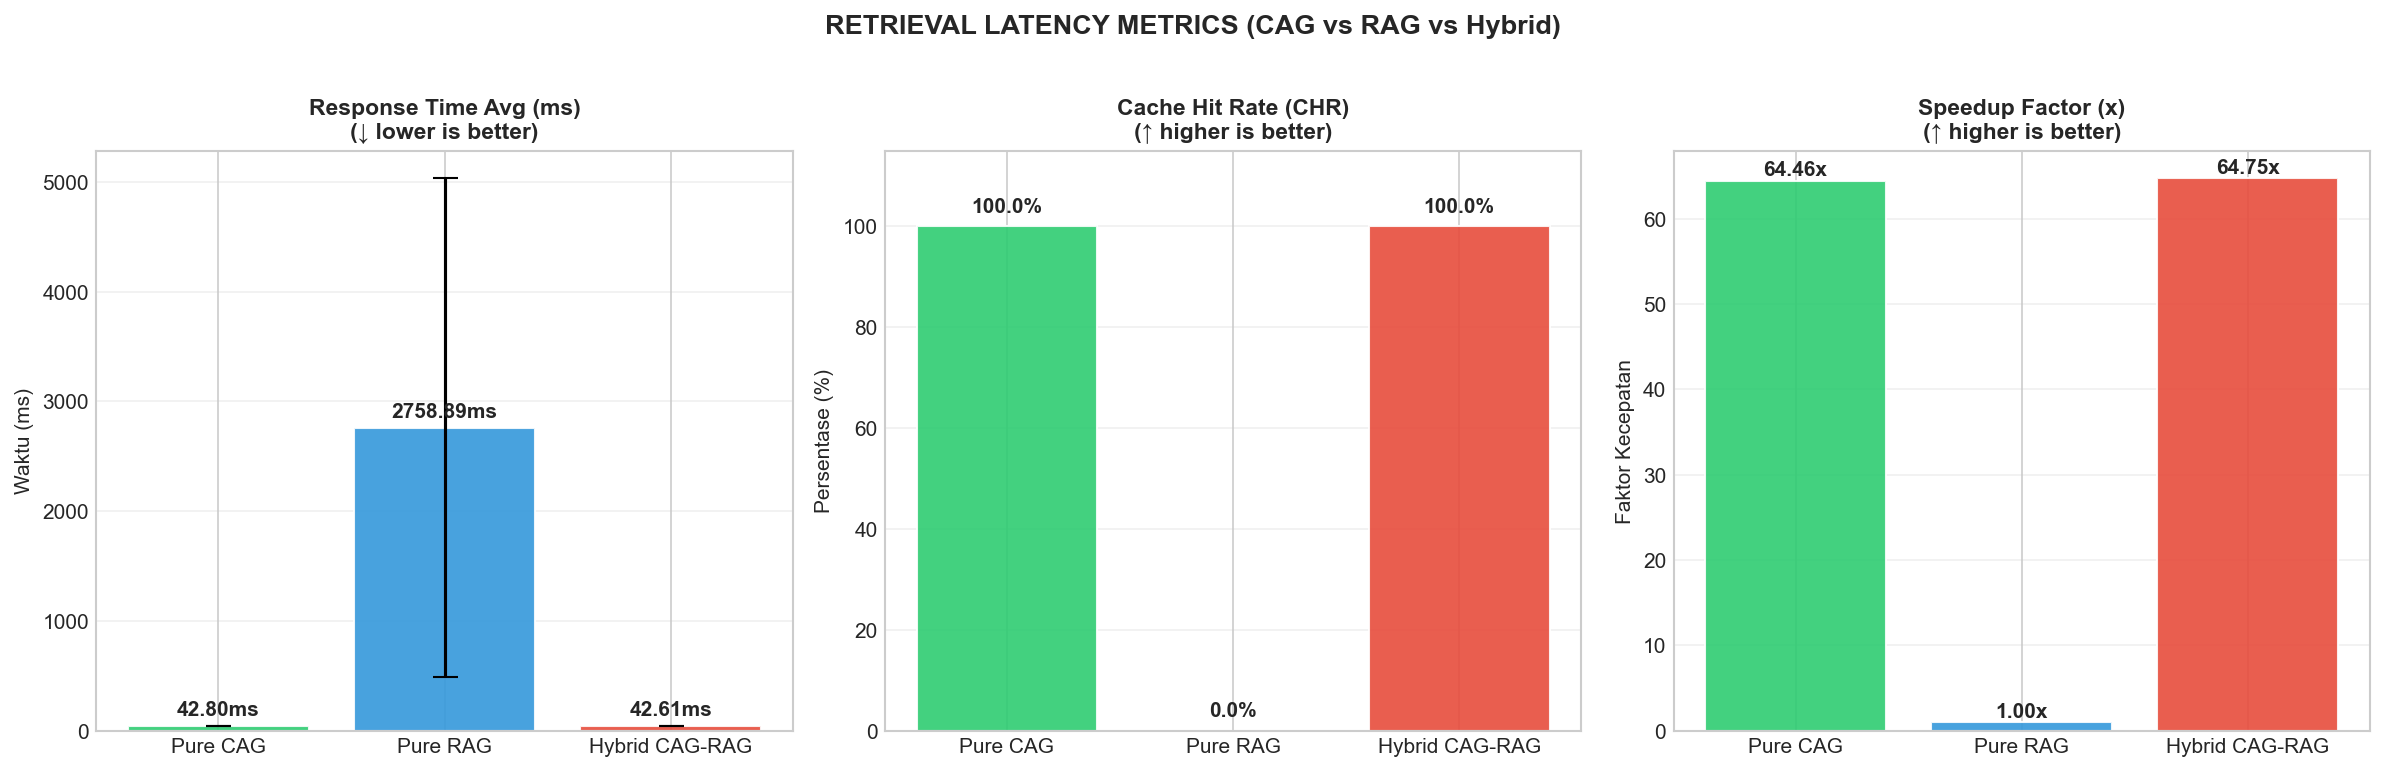

✅ Saved: logs/thesis_charts/retrieval_latency_metrics.png


In [42]:
# [Cell 55]
# ============================================================================
# VISUALISASI 1: RETRIEVAL LATENCY METRICS (Response Time, CHR, Speedup)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
import os

# Setup style visualisasi ilmiah
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
})

COLORS = {'CAG': '#2ecc71', 'RAG': '#3498db', 'HYBRID': '#e74c3c'}
LABELS = {'CAG': 'Pure CAG', 'RAG': 'Pure RAG', 'HYBRID': 'Hybrid CAG-RAG'}

frameworks = [f for f in ['CAG', 'RAG', 'HYBRID'] if framework_metrics.get(f)]

# Data Preparation — ubah ke ms
times = [float(framework_metrics[fw]['time_avg']) * 1000 for fw in frameworks]  # ← kali 1000
stds  = [float(framework_metrics[fw]['time_std'])  * 1000 for fw in frameworks]  # ← kali 1000
chrs = [float(framework_metrics[fw]['chr']) * 100 for fw in frameworks]

# Menghitung Speedup Factor
speedup_cag = (framework_metrics['RAG']['time_avg'] / framework_metrics['CAG']['time_avg']) if 'CAG' in frameworks else 1.0
speedup_hybrid = (framework_metrics['RAG']['time_avg'] / framework_metrics['HYBRID']['time_avg']) if 'HYBRID' in frameworks else 1.0
speedups = [speedup_cag if fw == 'CAG' else (speedup_hybrid if fw == 'HYBRID' else 1.0) for fw in frameworks]

# Membuat 3 Subplot Bersisian
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# Subplot 1: Response Time Avg — ubah label & format
bars1 = ax1.bar([LABELS[f] for f in frameworks], times, yerr=stds, capsize=6, color=[COLORS[f] for f in frameworks], edgecolor='white', alpha=0.9)
for bar, val in zip(bars1, times):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times)*0.02,
             f'{val:.2f}ms', ha='center', va='bottom', fontweight='bold')  # ← format ms
ax1.set_title('Response Time Avg (ms)\n(↓ lower is better)', fontweight='bold')  # ← judul ms
ax1.set_ylabel('Waktu (ms)')  # ← label ms
ax1.grid(axis='y', alpha=0.3)


# Subplot 2: Cache Hit Rate (CHR)
bars2 = ax2.bar([LABELS[f] for f in frameworks], chrs, color=[COLORS[f] for f in frameworks], edgecolor='white', alpha=0.9)
for bar, val in zip(bars2, chrs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax2.set_title('Cache Hit Rate (CHR)\n(↑ higher is better)', fontweight='bold')
ax2.set_ylabel('Persentase (%)')
ax2.set_ylim(0, 115)
ax2.grid(axis='y', alpha=0.3)

# Subplot 3: Speedup Factor
bars3 = ax3.bar([LABELS[f] for f in frameworks], speedups, color=[COLORS[f] for f in frameworks], edgecolor='white', alpha=0.9)
for bar, val in zip(bars3, speedups):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}x', ha='center', va='bottom', fontweight='bold')
ax3.set_title('Speedup Factor (x)\n(↑ higher is better)', fontweight='bold')
ax3.set_ylabel('Faktor Kecepatan')
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('RETRIEVAL LATENCY METRICS (CAG vs RAG vs Hybrid)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('../logs/thesis_charts', exist_ok=True)
plt.savefig('../logs/thesis_charts/retrieval_latency_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: logs/thesis_charts/retrieval_latency_metrics.png")


## [Cell 56] 2. Retrieval Inaccuracy Metrics (CAG vs RAG vs Hybrid)

Metrik ini digunakan untuk mengukur kualitas jawaban dan ketepatan informasi yang dihasilkan. Terdiri dari:
* **Relevance Score (0-1):** Kesesuaian jawaban dengan pertanyaan pengguna.
* **Exact Match (EM) (0-1):** Akurasi kecocokan persis jawaban dengan ground truth.
* **Effective Information Rate (EIR) (0-1):** Proporsi informasi berguna dalam konteks retrieval.
* **RAG Recall (0-1):** Kelengkapan informasi yang berhasil diambil.
* **BERTScore F1 (0-1):** Kemiripan semantik jawaban menggunakan model BERT.
* **Completeness (0-1):** Seberapa lengkap jawaban mencakup poin-poin penting.
* **Hallucination Rate (0-1):** Proporsi informasi yang tidak didukung atau bertentangan dengan konteks asli.

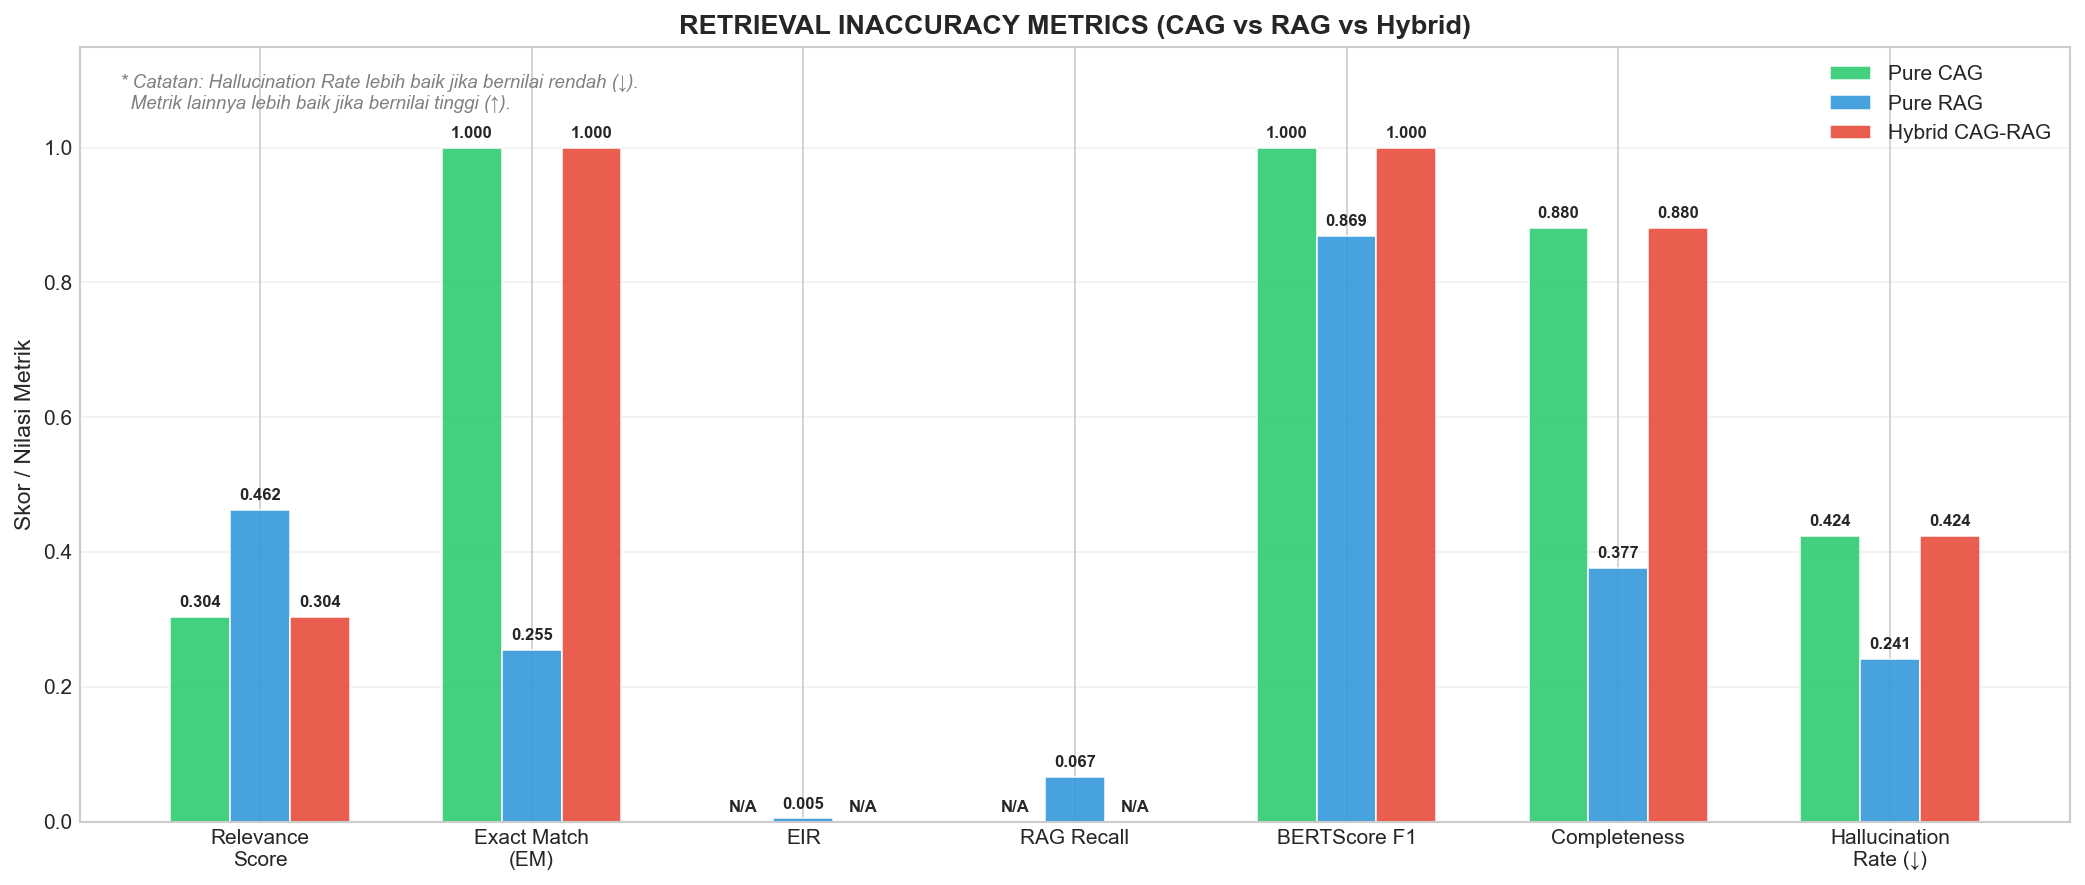

✅ Saved: logs/thesis_charts/retrieval_inaccuracy_metrics.png


In [43]:
# [Cell 57]
# ============================================================================
# VISUALISASI 2: RETRIEVAL INACCURACY METRICS (7 Metrik Kualitas)
# ============================================================================
inaccuracy_keys = ['rel', 'em', 'eir', 'recall', 'bert', 'comp', 'hall']
inaccuracy_labels = [
    'Relevance\nScore', 
    'Exact Match\n(EM)', 
    'EIR', 
    'RAG Recall', 
    'BERTScore F1', 
    'Completeness', 
    'Hallucination\nRate (↓)'
]

width = 0.22
x = np.arange(len(inaccuracy_keys))
fig, ax = plt.subplots(figsize=(14, 6))

def _safe(v):
    return 0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v

def _label(v):
    return "N/A" if v is None or (isinstance(v, float) and np.isnan(v)) else f"{v:.3f}"

# Membuat grafik batang terkelompok untuk ke-7 metrik
for idx, fw in enumerate(frameworks):
    raw_vals = [framework_metrics[fw].get(k) for k in inaccuracy_keys]
    vals = [_safe(v) for v in raw_vals]
    offset = (idx - (len(frameworks) - 1) / 2) * width
    
    bars = ax.bar(
        x + offset, vals, width, 
        label=LABELS[fw], color=COLORS[fw], 
        edgecolor='white', linewidth=0.8, alpha=0.9
    )
    
    for bar, v_raw in zip(bars, raw_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                _label(v_raw), ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(inaccuracy_labels, fontsize=10)
ax.set_ylabel('Skor / Nilasi Metrik', fontsize=11)
ax.set_title('RETRIEVAL INACCURACY METRICS (CAG vs RAG vs Hybrid)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

# Informasi tambahan mengenai arah pembacaan metrik
ax.annotate('* Catatan: Hallucination Rate lebih baik jika bernilai rendah (↓).\n  Metrik lainnya lebih baik jika bernilai tinggi (↑).', 
            xy=(0.02, 0.92), xycoords='axes fraction', fontsize=9, fontstyle='italic', color='gray')

plt.tight_layout()
plt.savefig('../logs/thesis_charts/retrieval_inaccuracy_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: logs/thesis_charts/retrieval_inaccuracy_metrics.png")


## [Cell 58] 📊 1. Visualisasi Evaluasi - Pure CAG

Bagian ini menampilkan performa sistem **Pure CAG** (hanya menggunakan pencarian berbasis cache tanpa fallback ke RAG).

### A. Retrieval Latency Metrics (Pure CAG)
Mengukur rata-rata waktu respons dan Cache Hit Rate (CHR) dari Pure CAG.

### B. Retrieval Inaccuracy Metrics (Pure CAG)
Mengukur kualitas jawaban dan ketepatan informasi yang dihasilkan oleh Pure CAG.


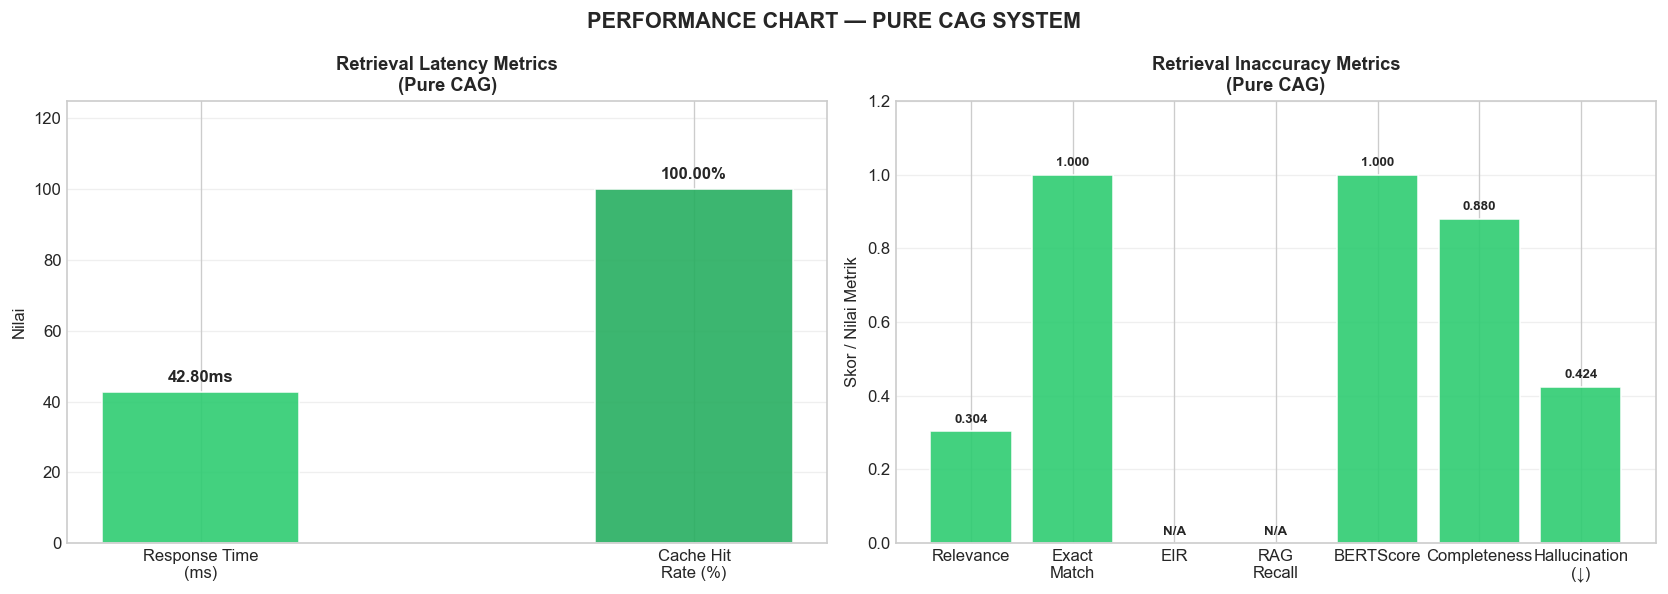

✅ Saved: pure_cag_performance.png


In [44]:
# [Cell 59]
# ============================================================================
# VISUALISASI PURE CAG (LATENCY & INACCURACY)
# ============================================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
COLORS_CAG = '#2ecc71'

# ── Subplot 1: Latency (tampilkan dalam ms agar tidak 0.000x) ──
latency_ms = float(pure_cag_m['time_avg']) * 1000
latency_std_ms = float(pure_cag_m['time_std']) * 1000
chr_val = float(pure_cag_m['chr']) * 100

categories = ['Response Time\n(ms)', 'Cache Hit\nRate (%)']
values = [latency_ms, chr_val]
colors = ['#2ecc71', '#27ae60']

bars1 = ax1.bar(categories, values, color=colors, edgecolor='white', width=0.4, alpha=0.9)
for bar, val, unit in zip(bars1, values, ['ms', '%']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.02,
             f'{val:.2f}{unit}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax1.set_title('Retrieval Latency Metrics\n(Pure CAG)', fontweight='bold', fontsize=11)
ax1.set_ylabel('Nilai')
ax1.set_ylim(0, max(values) * 1.25)
ax1.grid(axis='y', alpha=0.3)

# ── Subplot 2: Inaccuracy Metrics ──
inaccuracy_keys = ['rel', 'em', 'eir', 'recall', 'bert', 'comp', 'hall']
inaccuracy_labels = ['Relevance', 'Exact\nMatch', 'EIR', 'RAG\nRecall', 'BERTScore', 'Completeness', 'Hallucination\n(↓)']

raw_vals = [pure_cag_m.get(k) for k in inaccuracy_keys]
vals = [0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v for v in raw_vals]

bar_colors = ['#2ecc71' if not (v is None or (isinstance(v, float) and np.isnan(v))) else '#cccccc' for v in raw_vals]
bars2 = ax2.bar(inaccuracy_labels, vals, color=bar_colors, edgecolor='white', alpha=0.9)

for bar, v_raw in zip(bars2, raw_vals):
    lbl = "N/A" if v_raw is None or (isinstance(v_raw, float) and np.isnan(v_raw)) else f"{v_raw:.3f}"
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             lbl, ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.set_title('Retrieval Inaccuracy Metrics\n(Pure CAG)', fontweight='bold', fontsize=11)
ax2.set_ylabel('Skor / Nilai Metrik')
ax2.set_ylim(0, 1.2)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('PERFORMANCE CHART — PURE CAG SYSTEM', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('../logs/thesis_charts', exist_ok=True)
plt.savefig('../logs/thesis_charts/pure_cag_performance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: pure_cag_performance.png")


## [Cell 60] 📊 2. Visualisasi Evaluasi - Pure RAG

Bagian ini menampilkan performa sistem **Pure RAG** (pencarian dokumen berbasis vector database dan generasi respons, tanpa cache).

### A. Retrieval Latency Metrics (Pure RAG)
Mengukur rata-rata waktu respons dan Cache Hit Rate (CHR) dari Pure RAG.

### B. Retrieval Inaccuracy Metrics (Pure RAG)
Mengukur kualitas jawaban dan ketepatan informasi yang dihasilkan oleh Pure RAG.


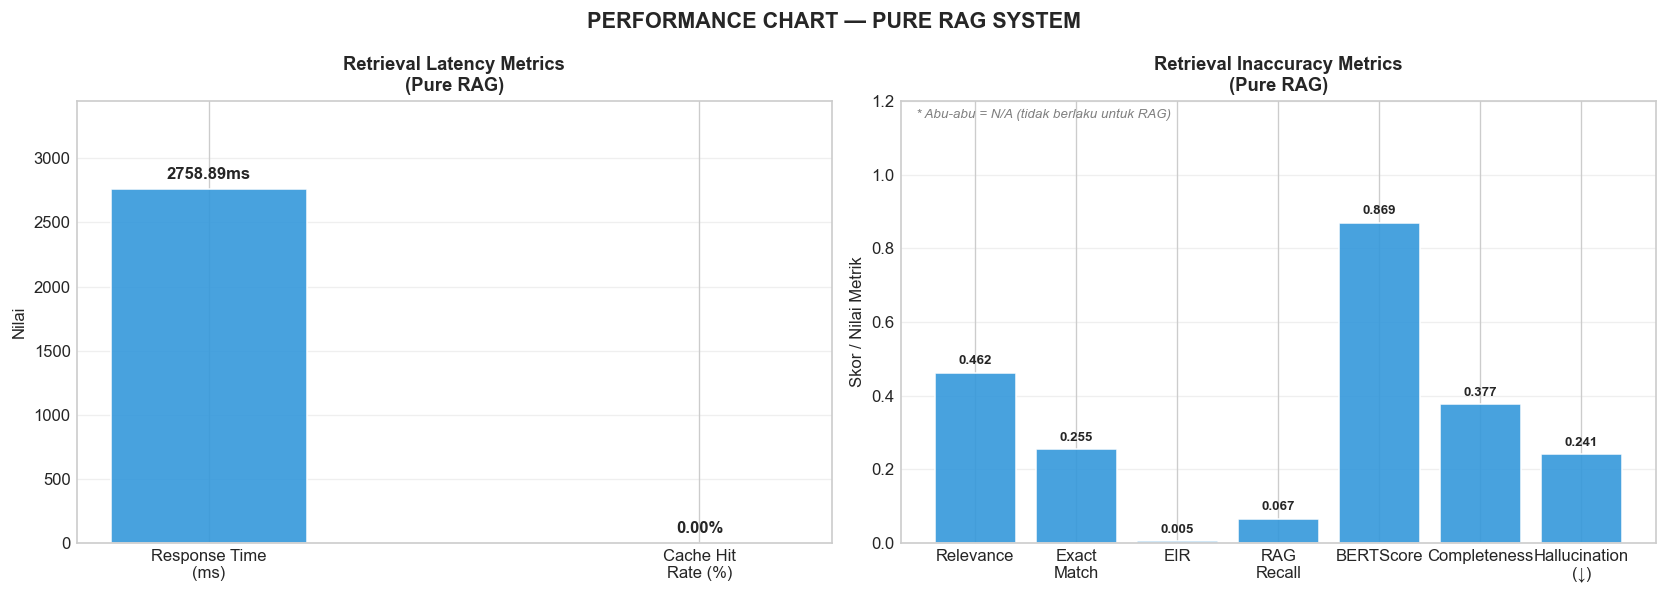

✅ Saved: pure_rag_performance.png


In [45]:
# [Cell 61]
# ============================================================================
# VISUALISASI PURE RAG (LATENCY & INACCURACY)
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Subplot 1: Latency ──
latency_ms = float(rag_m['time_avg']) * 1000
latency_std_ms = float(rag_m['time_std']) * 1000
chr_val_rag = float(rag_m['chr']) * 100

categories = ['Response Time\n(ms)', 'Cache Hit\nRate (%)']
values = [latency_ms, chr_val_rag]
colors = ['#3498db', '#2980b9']

bars1 = ax1.bar(categories, values, color=colors, edgecolor='white', width=0.4, alpha=0.9)
for bar, val, unit in zip(bars1, values, ['ms', '%']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.02,
             f'{val:.2f}{unit}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax1.set_title('Retrieval Latency Metrics\n(Pure RAG)', fontweight='bold', fontsize=11)
ax1.set_ylabel('Nilai')
ax1.set_ylim(0, max(values) * 1.25)
ax1.grid(axis='y', alpha=0.3)

# ── Subplot 2: Inaccuracy Metrics ──
raw_vals = [rag_m.get(k) for k in inaccuracy_keys]
vals = [0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v for v in raw_vals]

# Warna abu jika N/A
bar_colors = ['#3498db' if not (v is None or (isinstance(v, float) and np.isnan(v))) else '#cccccc' for v in raw_vals]
bars2 = ax2.bar(inaccuracy_labels, vals, color=bar_colors, edgecolor='white', alpha=0.9)

for bar, v_raw in zip(bars2, raw_vals):
    lbl = "N/A" if v_raw is None or (isinstance(v_raw, float) and np.isnan(v_raw)) else f"{v_raw:.3f}"
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             lbl, ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.set_title('Retrieval Inaccuracy Metrics\n(Pure RAG)', fontweight='bold', fontsize=11)
ax2.set_ylabel('Skor / Nilai Metrik')
ax2.set_ylim(0, 1.2)
ax2.grid(axis='y', alpha=0.3)

# Catatan untuk N/A
ax2.annotate('* Abu-abu = N/A (tidak berlaku untuk RAG)',
             xy=(0.02, 0.96), xycoords='axes fraction', fontsize=8, fontstyle='italic', color='gray')

plt.suptitle('PERFORMANCE CHART — PURE RAG SYSTEM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../logs/thesis_charts/pure_rag_performance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: pure_rag_performance.png")


## [Cell 62] 📊 3. Visualisasi Evaluasi - Hybrid CAG-RAG

Bagian ini menampilkan performa sistem **Hybrid CAG-RAG** (pencarian berbasis cache terlebih dahulu, lalu beralih ke RAG jika terjadi cache-miss).

### A. Retrieval Latency Metrics (Hybrid CAG-RAG)
Mengukur rata-rata waktu respons dan Cache Hit Rate (CHR) dari Hybrid CAG-RAG.

### B. Retrieval Inaccuracy Metrics (Hybrid CAG-RAG)
Mengukur kualitas jawaban dan ketepatan informasi yang dihasilkan oleh Hybrid CAG-RAG.


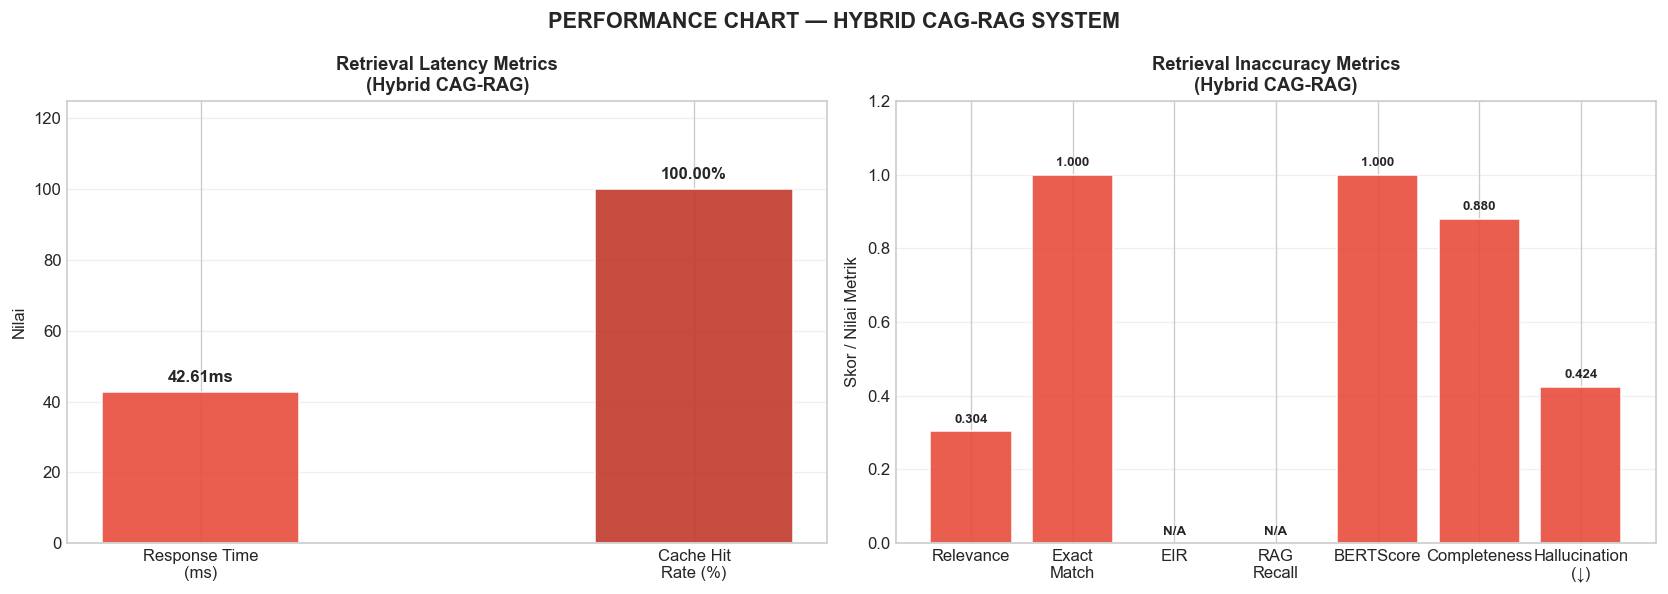

✅ Saved: hybrid_performance.png


In [46]:
# [Cell 63]
# ============================================================================
# VISUALISASI HYBRID CAG-RAG (LATENCY & INACCURACY)
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Subplot 1: Latency ──
latency_ms = float(cag_m['time_avg']) * 1000
latency_std_ms = float(cag_m['time_std']) * 1000
chr_val_hybrid = float(cag_m['chr']) * 100

categories = ['Response Time\n(ms)', 'Cache Hit\nRate (%)']
values = [latency_ms, chr_val_hybrid]
colors = ['#e74c3c', '#c0392b']

bars1 = ax1.bar(categories, values, color=colors, edgecolor='white', width=0.4, alpha=0.9)
for bar, val, unit in zip(bars1, values, ['ms', '%']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.02,
             f'{val:.2f}{unit}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax1.set_title('Retrieval Latency Metrics\n(Hybrid CAG-RAG)', fontweight='bold', fontsize=11)
ax1.set_ylabel('Nilai')
ax1.set_ylim(0, max(values) * 1.25)
ax1.grid(axis='y', alpha=0.3)

# ── Subplot 2: Inaccuracy Metrics ──
raw_vals = [cag_m.get(k) for k in inaccuracy_keys]
vals = [0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v for v in raw_vals]

bar_colors = ['#e74c3c' if not (v is None or (isinstance(v, float) and np.isnan(v))) else '#cccccc' for v in raw_vals]
bars2 = ax2.bar(inaccuracy_labels, vals, color=bar_colors, edgecolor='white', alpha=0.9)

for bar, v_raw in zip(bars2, raw_vals):
    lbl = "N/A" if v_raw is None or (isinstance(v_raw, float) and np.isnan(v_raw)) else f"{v_raw:.3f}"
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             lbl, ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.set_title('Retrieval Inaccuracy Metrics\n(Hybrid CAG-RAG)', fontweight='bold', fontsize=11)
ax2.set_ylabel('Skor / Nilai Metrik')
ax2.set_ylim(0, 1.2)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('PERFORMANCE CHART — HYBRID CAG-RAG SYSTEM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../logs/thesis_charts/hybrid_performance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: hybrid_performance.png")


## [Cell 64] 📊 4. Perbandingan Overview (Semua Framework)

Bagian ini menyajikan perbandingan komparatif dari ketiga sistem (Pure CAG vs Pure RAG vs Hybrid CAG-RAG) untuk seluruh metrik evaluasi.

### A. Perbandingan Retrieval Latency Metrics (Waktu Respons, CHR, & Speedup)
### B. Perbandingan Retrieval Inaccuracy Metrics (7 Metrik Kualitas & Akurasi)


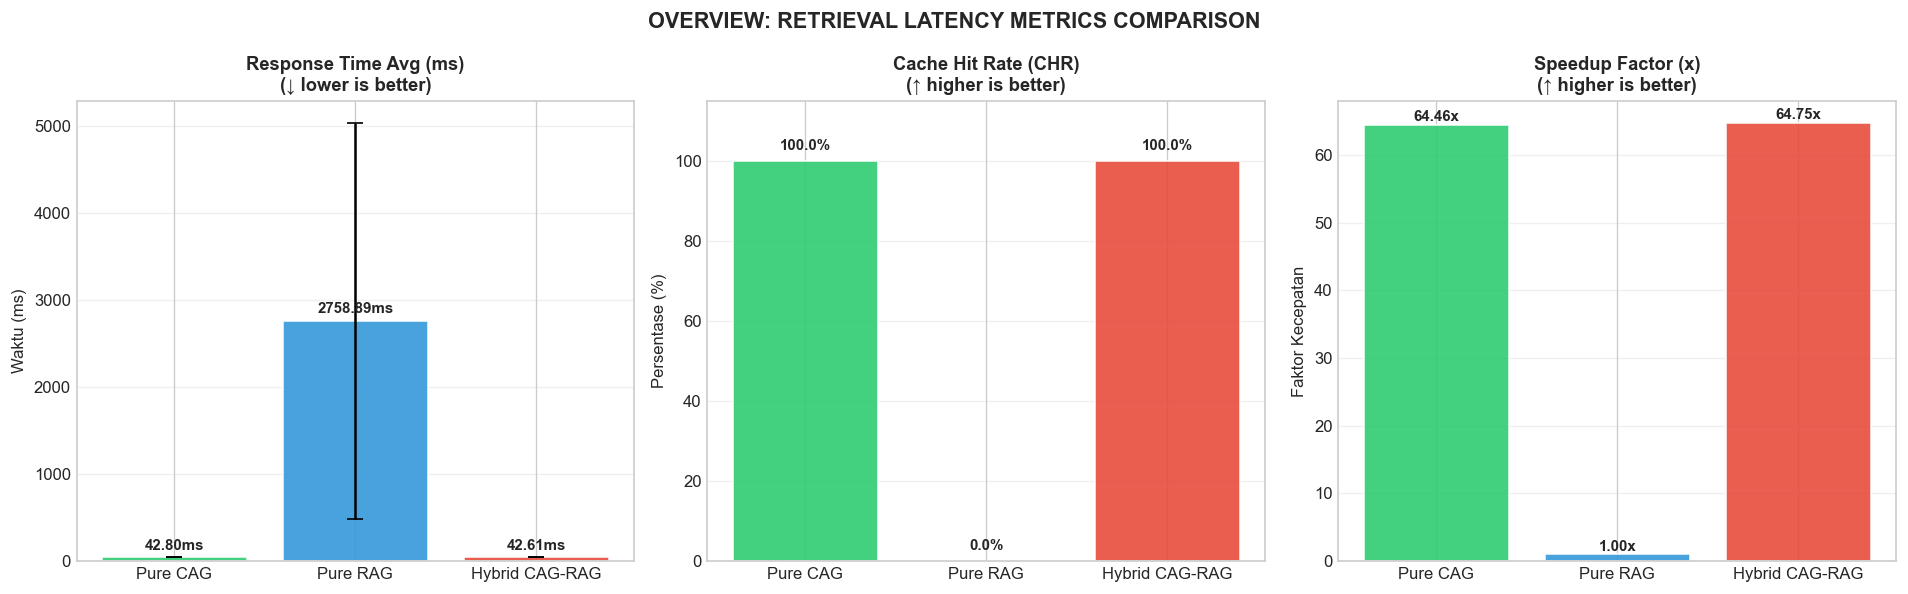

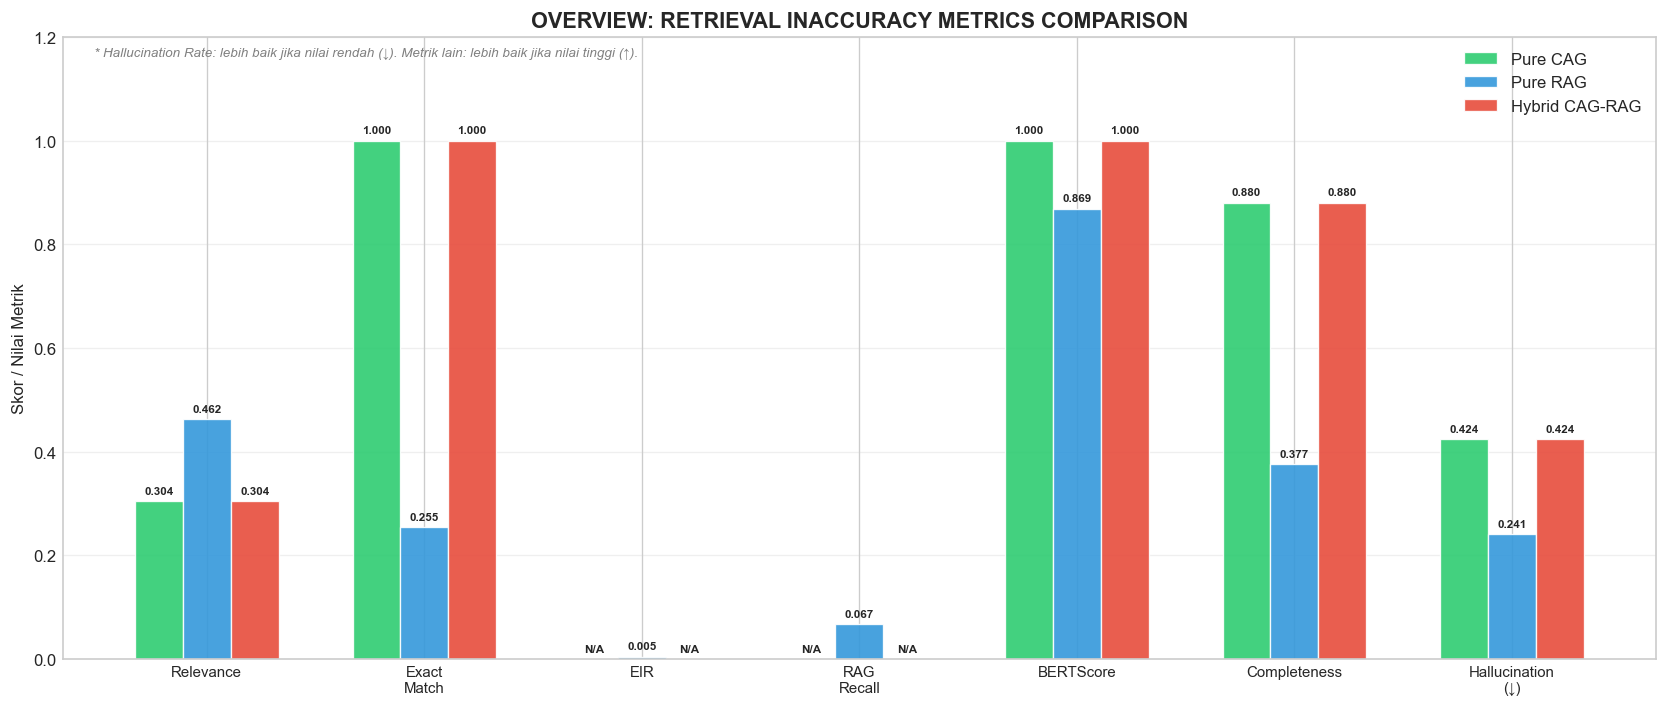

✅ Overview saved: overview_latency.png & overview_inaccuracy.png


In [47]:
# [Cell 65]
# ============================================================================
# OVERVIEW: PERBANDINGAN SEMUA FRAMEWORK
# Jalankan cell ini terakhir setelah semua framework divisualisasikan
# ============================================================================
COLORS = {'CAG': '#2ecc71', 'RAG': '#3498db', 'HYBRID': '#e74c3c'}
LABELS = {'CAG': 'Pure CAG', 'RAG': 'Pure RAG', 'HYBRID': 'Hybrid CAG-RAG'}

# Pastikan framework_metrics sudah terdefinisi
framework_metrics = {
    'CAG': pure_cag_m,
    'RAG': rag_m,
    'HYBRID': cag_m,
}
frameworks = [f for f in ['CAG', 'RAG', 'HYBRID'] if framework_metrics.get(f)]

# ── Bagian 1: Latency Comparison (dalam ms) ──
times_ms = [float(framework_metrics[fw]['time_avg']) * 1000 for fw in frameworks]
stds_ms = [float(framework_metrics[fw]['time_std']) * 1000 for fw in frameworks]
chrs = [float(framework_metrics[fw]['chr']) * 100 for fw in frameworks]
speedup_cag = (framework_metrics['RAG']['time_avg'] / framework_metrics['CAG']['time_avg']) if 'CAG' in frameworks and framework_metrics['CAG']['time_avg'] > 0 else 1.0
speedup_hybrid = (framework_metrics['RAG']['time_avg'] / framework_metrics['HYBRID']['time_avg']) if 'HYBRID' in frameworks and framework_metrics['HYBRID']['time_avg'] > 0 else 1.0
speedups = [speedup_cag if fw == 'CAG' else (speedup_hybrid if fw == 'HYBRID' else 1.0) for fw in frameworks]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

bars1 = ax1.bar([LABELS[f] for f in frameworks], times_ms, yerr=stds_ms, capsize=5,
                color=[COLORS[f] for f in frameworks], edgecolor='white', alpha=0.9)
for bar, val in zip(bars1, times_ms):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times_ms)*0.02,
             f'{val:.2f}ms', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax1.set_title('Response Time Avg (ms)\n(↓ lower is better)', fontweight='bold')
ax1.set_ylabel('Waktu (ms)')
ax1.grid(axis='y', alpha=0.3)

bars2 = ax2.bar([LABELS[f] for f in frameworks], chrs,
                color=[COLORS[f] for f in frameworks], edgecolor='white', alpha=0.9)
for bar, val in zip(bars2, chrs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax2.set_title('Cache Hit Rate (CHR)\n(↑ higher is better)', fontweight='bold')
ax2.set_ylabel('Persentase (%)')
ax2.set_ylim(0, 115)
ax2.grid(axis='y', alpha=0.3)

bars3 = ax3.bar([LABELS[f] for f in frameworks], speedups,
                color=[COLORS[f] for f in frameworks], edgecolor='white', alpha=0.9)
for bar, val in zip(bars3, speedups):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}x', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax3.set_title('Speedup Factor (x)\n(↑ higher is better)', fontweight='bold')
ax3.set_ylabel('Faktor Kecepatan')
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('OVERVIEW: RETRIEVAL LATENCY METRICS COMPARISON', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../logs/thesis_charts/overview_latency.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ── Bagian 2: Inaccuracy Comparison (7 Metrik) ──
width = 0.22
x = np.arange(len(inaccuracy_keys))
fig2, ax = plt.subplots(figsize=(14, 6))

for idx, fw in enumerate(frameworks):
    raw_vals = [framework_metrics[fw].get(k) for k in inaccuracy_keys]
    vals = [0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v for v in raw_vals]
    offset = (idx - (len(frameworks) - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width, label=LABELS[fw],
                  color=COLORS[fw], edgecolor='white', linewidth=0.8, alpha=0.9)
    for bar, v_raw in zip(bars, raw_vals):
        lbl = "N/A" if v_raw is None or (isinstance(v_raw, float) and np.isnan(v_raw)) else f"{v_raw:.3f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                lbl, ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(inaccuracy_labels, fontsize=9)
ax.set_ylabel('Skor / Nilai Metrik')
ax.set_title('OVERVIEW: RETRIEVAL INACCURACY METRICS COMPARISON', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.2)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
ax.annotate('* Hallucination Rate: lebih baik jika nilai rendah (↓). Metrik lain: lebih baik jika nilai tinggi (↑).',
            xy=(0.02, 0.97), xycoords='axes fraction', fontsize=8, fontstyle='italic', color='gray')

plt.tight_layout()
plt.savefig('../logs/thesis_charts/overview_inaccuracy.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Overview saved: overview_latency.png & overview_inaccuracy.png")


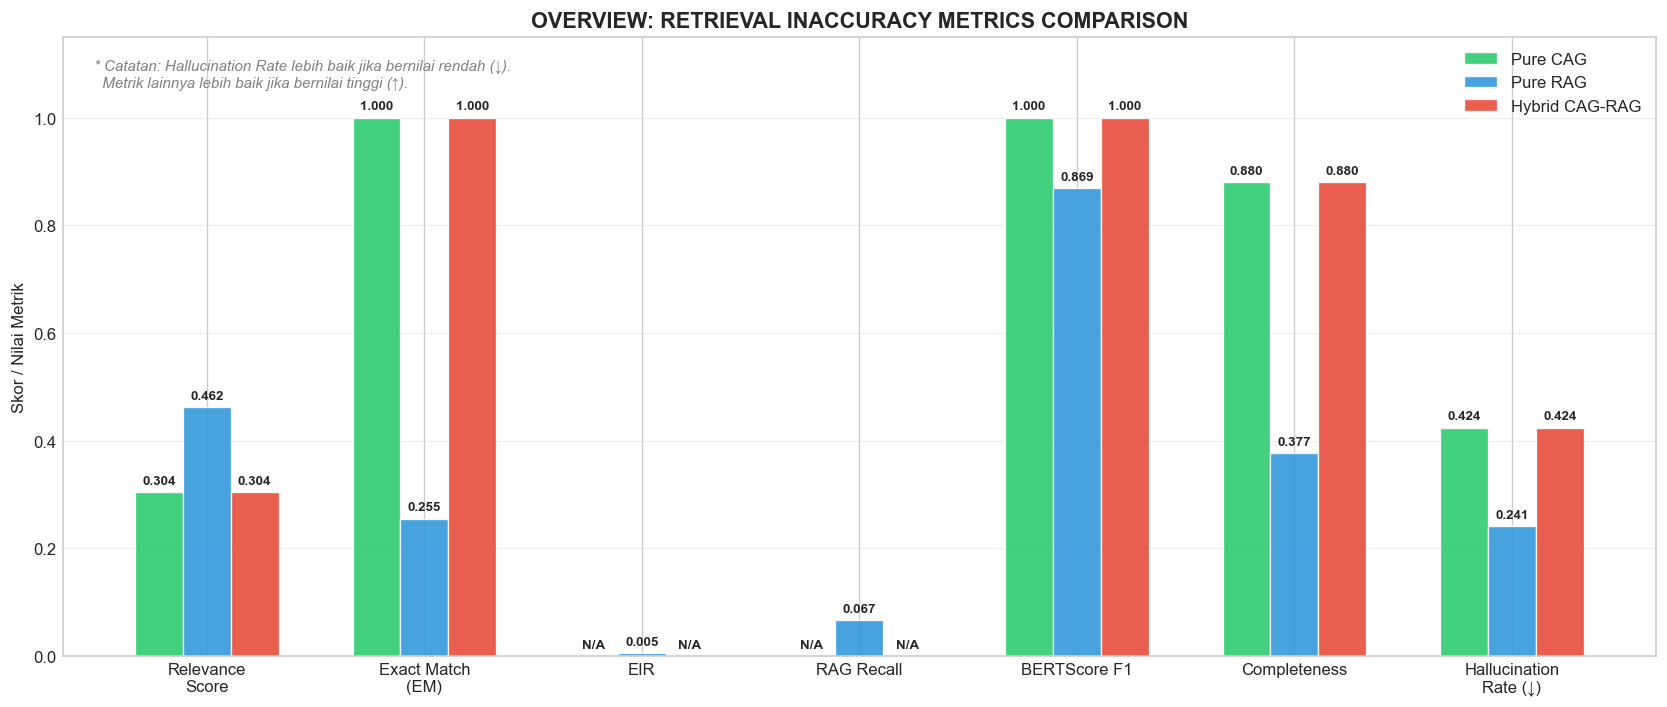

In [48]:
# [Cell 66]
# ============================================================================
# OVERVIEW: INACCURACY COMPARISON (7 METRICS GROUPED)
# ============================================================================
width = 0.22
x = np.arange(len(inaccuracy_keys))
fig, ax = plt.subplots(figsize=(14, 6))

for idx, fw in enumerate(frameworks):
    raw_vals = [framework_metrics[fw].get(k) for k in inaccuracy_keys]
    vals = [0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v for v in raw_vals]
    offset = (idx - (len(frameworks) - 1) / 2) * width
    
    bars = ax.bar(
        x + offset, vals, width, 
        label=LABELS[fw], color=COLORS[fw], 
        edgecolor='white', linewidth=0.8, alpha=0.9
    )
    
    for bar, v_raw in zip(bars, raw_vals):
        lbl = "N/A" if v_raw is None or (isinstance(v_raw, float) and np.isnan(v_raw)) else f"{v_raw:.3f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                lbl, ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([
    'Relevance\nScore', 'Exact Match\n(EM)', 'EIR', 
    'RAG Recall', 'BERTScore F1', 'Completeness', 'Hallucination\nRate (↓)'
], fontsize=10)
ax.set_ylabel('Skor / Nilai Metrik')
ax.set_title('OVERVIEW: RETRIEVAL INACCURACY METRICS COMPARISON', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

ax.annotate('* Catatan: Hallucination Rate lebih baik jika bernilai rendah (↓).\n  Metrik lainnya lebih baik jika bernilai tinggi (↑).', 
            xy=(0.02, 0.92), xycoords='axes fraction', fontsize=9, fontstyle='italic', color='gray')

plt.tight_layout()
plt.savefig('../logs/thesis_charts/overview_inaccuracy_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


## [Cell 67] Statistical Significance Testing
Paired t-test (p < 0.05) + Cohen's d effect size.

🔬 STATISTICAL SIGNIFICANCE TESTS (Paired t-test, NaN-aware)
   H0: No difference between RAG and Hybrid CAG-RAG
   H1: Significant difference exists (p < 0.05)
   NaN positions (no-context path) are excluded from all tests.

  Metric                     N   RAG µ   CAG µ   t-stat   p-value       d  Result
  ----------------------------------------------------------------------------------
  Response Time            200  2.7589  0.0426   16.852    0.0000   1.192  ✅ H1 supported
  Relevance Score          200  0.4620  0.3038    8.942    0.0000   0.632  ⚠️  sig. but reversed
  Exact Match              200  0.2550  1.0000  -24.112    0.0000   1.705  ✅ H1 supported
  EIR                     (no valid pairs after NaN removal — skipped)
  RAG Recall              (no valid pairs after NaN removal — skipped)
  BERTScore F1             200  0.8689  1.0000  -23.692    0.0000   1.675  ✅ H1 supported
  Completeness             200  0.3767  0.8804  -13.951    0.0000   0.986  ✅ H1 supported
  Halluci

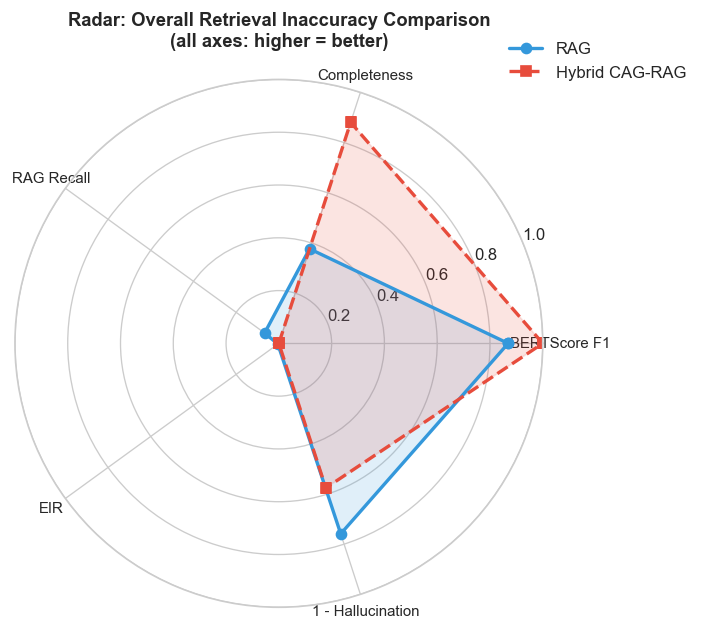

✅ Saved: logs/radar_comparison.png


In [49]:
# [Cell 68]
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt

# 1. Pendefinisian helper function untuk Paired T-Test (NaN-aware)
def paired_ttest(a, b):
    # Filter pasangan data yang bernilai NaN atau None
    valid_pairs = []
    for x, y in zip(a, b):
        if x is None or y is None:
            continue
        if isinstance(x, (int, float)) and np.isnan(x):
            continue
        if isinstance(y, (int, float)) and np.isnan(y):
            continue
        valid_pairs.append((float(x), float(y)))
        
    n_valid = len(valid_pairs)
    if n_valid < 2:
        return float('nan'), float('nan'), n_valid
        
    a_clean = [p[0] for p in valid_pairs]
    b_clean = [p[1] for p in valid_pairs]
    res = stats.ttest_rel(a_clean, b_clean)
    return res.statistic, res.pvalue, n_valid

# 2. Pendefinisian helper function untuk Cohen's d (NaN-aware)
def cohens_d(a, b):
    # Filter pasangan data yang bernilai NaN atau None
    valid_pairs = []
    for x, y in zip(a, b):
        if x is None or y is None:
            continue
        if isinstance(x, (int, float)) and np.isnan(x):
            continue
        if isinstance(y, (int, float)) and np.isnan(y):
            continue
        valid_pairs.append((float(x), float(y)))
        
    n_valid = len(valid_pairs)
    if n_valid < 2:
        return float('nan')
        
    diffs = np.array([p[0] - p[1] for p in valid_pairs])
    mean_diff = np.mean(diffs)
    std_diff = np.std(diffs, ddof=1)
    if std_diff == 0:
        return 0.0
    return abs(mean_diff) / std_diff

# 3. STATISTICAL SIGNIFICANCE TESTING (Paired t-test + Cohen's d)
if not cag_m:
    print("⚠️  CAG results not available, skipping statistical tests.")
else:
    print("=" * 72)
    print("🔬 STATISTICAL SIGNIFICANCE TESTS (Paired t-test, NaN-aware)")
    print("   H0: No difference between RAG and Hybrid CAG-RAG")
    print("   H1: Significant difference exists (p < 0.05)")
    print("   NaN positions (no-context path) are excluded from all tests.")
    print("=" * 72)

    # Metrik yang diuji — arah = 'lower' → CAG harus lebih rendah, 'higher' → CAG harus lebih tinggi
    test_metrics = [
        # (label,               rag_list,             cag_list,             better_direction)
        # ── Latency ──────────────────────────────────────────────────────────
        ("Response Time",      rag_m['_time'],       cag_m['_time'],       "lower"),
        # ── Relevance ─────────────────────────────────────────────────────────
        ("Relevance Score",    rag_m['_rel'],        cag_m['_rel'],        "higher"),
        # ── Retrieval / Answer Alignment ─────────────────────────────────────
        ("Exact Match",        rag_m['_em'],         cag_m['_em'],         "higher"),
        ("EIR",                rag_m['_eir'],        cag_m['_eir'],        "higher"),
        ("RAG Recall",         rag_m['_recall'],     cag_m['_recall'],     "higher"),
        ("BERTScore F1",       rag_m['_bert'],       cag_m['_bert'],       "higher"),
        ("Completeness",       rag_m['_comp'],       cag_m['_comp'],       "higher"),
        # ── Inaccuracy ────────────────────────────────────────────────────────
        ("Hallucination Rate", rag_m['_hall'],       cag_m['_hall'],       "lower"),
    ]

    stat_rows = []
    print(f"\n  {'Metric':<22} {'N':>5} {'RAG µ':>7} {'CAG µ':>7} {'t-stat':>8} {'p-value':>9} {'d':>7}  Result")
    print("  " + "-" * 82)

    for lbl, rag_vals, cag_vals, direction in test_metrics:
        if len(rag_vals) < 2 or len(cag_vals) < 2:
            print(f"  {lbl:<22}  (insufficient data — need ≥ 2 queries)")
            continue

        t_stat, p_val, n_valid = paired_ttest(rag_vals, cag_vals)
        d                      = cohens_d(rag_vals, cag_vals)

        if n_valid < 2:
            print(f"  {lbl:<22}  (no valid pairs after NaN removal — skipped)")
            continue

        # Means computed only on non-NaN values for fair representation
        rag_clean = [x for x in rag_vals if not (isinstance(x, (int, float)) and np.isnan(x))]
        cag_clean = [x for x in cag_vals if not (isinstance(x, (int, float)) and np.isnan(x))]
        rag_mu    = round(float(np.mean(rag_clean)), 4) if rag_clean else float('nan')
        cag_mu    = round(float(np.mean(cag_clean)), 4) if cag_clean else float('nan')

        significant = not np.isnan(p_val) and p_val < 0.05

        # Check if direction is as expected
        if direction == "lower":
            direction_ok = cag_mu <= rag_mu
        else:
            direction_ok = cag_mu >= rag_mu

        if significant and direction_ok:
            result = "✅ H1 supported"
        elif significant and not direction_ok:
            result = "⚠️  sig. but reversed"
        else:
            result = "❌ not significant"

        n_str = f"{n_valid}" if n_valid == len(rag_vals) else f"{n_valid}*"
        print(f"  {lbl:<22} {n_str:>5} {rag_mu:>7.4f} {cag_mu:>7.4f} "
              f"{t_stat:>8.3f} {p_val:>9.4f} {d:>7.3f}  {result}")
        
        stat_rows.append({
            'Metric': lbl, 'N': n_valid, 'RAG_mean': rag_mu, 'CAG_mean': cag_mu,
            't_stat': t_stat, 'p_value': p_val, "Cohen_d": d,
            'significant': significant, 'direction_ok': direction_ok
        })

    print("\n  * N < total = beberapa posisi NaN (no-context path) dikecualikan")
    print("  Legend: ✅ Hypothesis supported  |  ❌ Not significant  |  ⚠️  Unexpected direction")
    print(f"  α = 0.05  |  Effect size: small < 0.2,  medium 0.2–0.8,  large > 0.8")

    # Radar chart for visual comparison
    stat_df = pd.DataFrame(stat_rows)

    # Radar chart
    radar_metrics = ['BERTScore F1', 'Completeness', 'RAG Recall', 'EIR']
    rag_radar  = [rag_m['bert'], rag_m['comp'], rag_m['recall'], rag_m['eir']]
    cag_radar  = [cag_m['bert'], cag_m['comp'], cag_m['recall'], cag_m['eir']]

    # Invert inaccuracy metrics so higher = better on radar
    # Guard against NaN for hallucination (no-context path excluded from mean already)
    rag_hall_val = rag_m['hall'] if not (isinstance(rag_m['hall'], (int, float)) and np.isnan(rag_m['hall'])) else 0.5
    cag_hall_val = cag_m['hall'] if not (isinstance(cag_m['hall'], (int, float)) and np.isnan(cag_m['hall'])) else 0.5

    radar_metrics += ['1 - Hallucination']
    rag_radar  += [1 - rag_hall_val]
    cag_radar  += [1 - cag_hall_val]

    # Replace any remaining NaN with 0 for radar chart rendering
    rag_radar = [v if not (isinstance(v, (int, float)) and np.isnan(v)) else 0.0 for v in rag_radar]
    cag_radar = [v if not (isinstance(v, (int, float)) and np.isnan(v)) else 0.0 for v in cag_radar]

    N   = len(radar_metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    rag_r  = rag_radar + [rag_radar[0]]
    cag_r  = cag_radar + [cag_radar[0]]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, rag_r, 'o-', color='#3498db', linewidth=2, label='RAG')
    ax.fill(angles, rag_r, alpha=0.15, color='#3498db')
    ax.plot(angles, cag_r, 's--', color='#e74c3c', linewidth=2, label='Hybrid CAG-RAG')
    ax.fill(angles, cag_r, alpha=0.15, color='#e74c3c')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title('Radar: Overall Retrieval Inaccuracy Comparison\n(all axes: higher = better)',
                 fontsize=11, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    plt.tight_layout()
    plt.savefig('../logs/radar_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: logs/radar_comparison.png")


## [Cell 69] Save & Export

In [50]:
# [Cell 70]
# Save & Export All Results

import json
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
os.makedirs('../logs', exist_ok=True)

speedup_hybrid = (rag_m['time_avg'] / cag_m['time_avg']) if (cag_m and cag_m['time_avg'] > 0) else None
speedup_cag    = (rag_m['time_avg'] / pure_cag_m['time_avg']) if (pure_cag_m and pure_cag_m['time_avg'] > 0) else None

cag_hits = sum(1 for x in pure_cag_res if x.get('cache')) if pure_cag_res else 0
hybrid_hits = sum(1 for x in cag_res if x.get('cache')) if cag_res else 0

# 1. Summary metrics JSON
summary_export = {
    'timestamp':    ts,
    'dataset_size': len(dataset),
    'rag': {k: v for k, v in rag_m.items() if not k.startswith('_') and k != 'per_query'},
    'cag_pure': ({k: v for k, v in pure_cag_m.items() if not k.startswith('_') and k != 'per_query'}
                 if pure_cag_m else None),
    'hybrid': ({k: v for k, v in cag_m.items() if not k.startswith('_') and k != 'per_query'}
               if cag_m else None),
    'speedup_hybrid': round(speedup_hybrid, 4) if speedup_hybrid else None,
    'speedup_cag': round(speedup_cag, 4) if speedup_cag else None,
    'cache_hits': {
        'cag_pure': cag_hits,
        'hybrid': hybrid_hits,
    },
}

json_path = f'../logs/eval_summary_{ts}.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(summary_export, f, indent=2, ensure_ascii=False)
print(f"Summary JSON     : {json_path}")

# 2. Per-query CSV — RAG
if rag_m['per_query']:
    rag_csv = f'../logs/eval_rag_perquery_{ts}.csv'
    pd.DataFrame(rag_m['per_query']).to_csv(rag_csv, index=False)
    print(f"RAG per-query    : {rag_csv}")

# 3. Per-query CSV — CAG (pure)
if pure_cag_m and pure_cag_m['per_query']:
    cag_csv = f'../logs/eval_cag_pure_perquery_{ts}.csv'
    pd.DataFrame(pure_cag_m['per_query']).to_csv(cag_csv, index=False)
    print(f"CAG per-query    : {cag_csv}")

# 4. Per-query CSV — Hybrid
if cag_m and cag_m['per_query']:
    hybrid_csv = f'../logs/eval_hybrid_perquery_{ts}.csv'
    pd.DataFrame(cag_m['per_query']).to_csv(hybrid_csv, index=False)
    print(f"Hybrid per-query : {hybrid_csv}")

# 5. Statistical results CSV
if cag_m and 'stat_df' in dir():
    stat_csv = f'../logs/eval_stats_{ts}.csv'
    stat_df.to_csv(stat_csv, index=False)
    print(f"Statistics       : {stat_csv}")

# Key Findings
print("\n" + "=" * 65)
print("KEY FINDINGS  —  CAG vs RAG vs Hybrid CAG-RAG")
print("=" * 65)

print(f"\n  RQ1 LATENCY")
if pure_cag_m:
    print(f"    CAG avg time   : {pure_cag_m['time_avg']:.3f}s +/- {pure_cag_m['time_std']:.3f}s")
    print(f"    CAG CHR        : {pure_cag_m['chr']:.1f}% ({cag_hits}/{len(pure_cag_res)})")
print(f"    RAG avg time   : {rag_m['time_avg']:.3f}s +/- {rag_m['time_std']:.3f}s")
if cag_m:
    print(f"    Hybrid avg time: {cag_m['time_avg']:.3f}s +/- {cag_m['time_std']:.3f}s")
    print(f"    Speedup (RAG/Hybrid): {speedup_hybrid:.2f}x" if speedup_hybrid else "    Speedup (RAG/Hybrid): N/A")
    print(f"    Hybrid CHR     : {cag_m['chr']:.1f}% ({hybrid_hits}/{len(cag_res)})")

print(f"\n  RQ2 INACCURACY")
if cag_m:
    hall_d = rag_m['hall'] - cag_m['hall']
    rel_d  = cag_m['rel']  - rag_m['rel']
    print(f"    Hallucination  RAG={rag_m['hall']:.4f}  Hybrid={cag_m['hall']:.4f}  delta={hall_d:+.4f}")
    print(f"    Relevance      RAG={rag_m['rel']:.4f}  Hybrid={cag_m['rel']:.4f}  delta={rel_d:+.4f}")

    print(f"\n  GROUND-TRUTH ALIGNMENT")
    print(f"    BERTScore F1   RAG={rag_m['bert']:.4f}  Hybrid={cag_m['bert']:.4f}  delta={cag_m['bert']-rag_m['bert']:+.4f}")
    print(f"    Completeness   RAG={rag_m['comp']:.4f}  Hybrid={cag_m['comp']:.4f}  delta={cag_m['comp']-rag_m['comp']:+.4f}")
    print(f"    Exact Match    RAG={rag_m['em']:.4f}  Hybrid={cag_m['em']:.4f}  delta={cag_m['em']-rag_m['em']:+.4f}")

print("\nEvaluation complete.")
print(f"Outputs saved to: logs/")

Summary JSON     : ../logs/eval_summary_20260617_113120.json
RAG per-query    : ../logs/eval_rag_perquery_20260617_113120.csv
CAG per-query    : ../logs/eval_cag_pure_perquery_20260617_113120.csv
Hybrid per-query : ../logs/eval_hybrid_perquery_20260617_113120.csv
Statistics       : ../logs/eval_stats_20260617_113120.csv

KEY FINDINGS  —  CAG vs RAG vs Hybrid CAG-RAG

  RQ1 LATENCY
    CAG avg time   : 0.043s +/- 0.001s
    CAG CHR        : 1.0% (200/200)
    RAG avg time   : 2.759s +/- 2.274s
    Hybrid avg time: 0.043s +/- 0.000s
    Speedup (RAG/Hybrid): 64.75x
    Hybrid CHR     : 1.0% (200/200)

  RQ2 INACCURACY
    Hallucination  RAG=0.2412  Hybrid=0.4239  delta=-0.1827
    Relevance      RAG=0.4620  Hybrid=0.3038  delta=-0.1582

  GROUND-TRUTH ALIGNMENT
    BERTScore F1   RAG=0.8689  Hybrid=1.0000  delta=+0.1311
    Completeness   RAG=0.3767  Hybrid=0.8804  delta=+0.5037
    Exact Match    RAG=0.2550  Hybrid=1.0000  delta=+0.7450

Evaluation complete.
Outputs saved to: logs/
